# Paper combined - train the edit model, then run BCO experiments

**PART 1** fine-tunes the final-experiments RTT + connectivity agent for 100 epochs on the current 500-graph curriculum with an adjustment-degree cap penalty (W=10, target=0.2, paper mode, demand off). **PART 2** runs the paper experiments (E1-E6) using that fine-tuned model as `OUR_MODEL_PATH`. Algorithm budgets are set for a full top-to-bottom run that should fit into roughly 25-30 hours on the current CPU calibration; rerun the timing estimator cell after any budget change.

Run top-to-bottom: training must finish before the experiment config picks up the trained weights.


In [1]:
import os
os.environ["CUDA_VISIBLE_DEVICES"] = "1"   # select GPU 1
import sys, pickle, shutil, json, random as _random
from pathlib import Path
from collections import Counter
import numpy as np, pandas as pd, torch
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation, PillowWriter
from hydra import compose, initialize_config_dir
from tqdm.auto import tqdm
from IPython.display import Image, display

from eval_lib.context import (ROOT_DIR, CFG_DIR, DATASETS_DIR,
                              MODEL_OUTPUTS_DIR, EDIT_MODEL_WEIGHTS_DIR)
if str(ROOT_DIR) not in sys.path:
    sys.path.insert(0, str(ROOT_DIR))
from connectpt.routes_generator import utils as lrnu
from connectpt.routes_generator.improvement_learning import (
    _get_planned_current_routes, _make_route_context_state,
    load_raw_graphs_and_lc_routes, make_improvement_batch,
    rollout_lc_improvement, train_lc_improvement_cfg)
from connectpt.routes_generator.torch_utils import (
    get_batch_tensor_from_routes, dump_routes)
from connectpt.routes_generator.transit_time_estimator import (
    ROUTE_ACTION_EXTEND, ROUTE_ACTION_HALT, ROUTE_ACTION_TRIM_END,
    ROUTE_ACTION_TRIM_START, RouteGenBatchState)
from connectpt.routes_generator.citygraph_dataset import (
    STOP_KEY, DynamicCityGraphDataset)
from connectpt.routes_generator.bee_colony import get_adjustment_degrees
from torch_geometric.data import Batch
from eval_lib.results_io import save_table
from eval_lib import build_lc_cfg, run_lc, as_route_tensor
from eval_lib import plots as route_plots

pd.set_option("display.max_columns", None)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("device:", device)

device: cpu


In [2]:
import os, sys
os.environ.setdefault("CUDA_VISIBLE_DEVICES", "1")
import numpy as np, pandas as pd, torch
import matplotlib.pyplot as plt
from collections import Counter
from IPython.display import display

from eval_lib.context import ROOT_DIR, EDIT_MODEL_WEIGHTS_DIR
if str(ROOT_DIR) not in sys.path:
    sys.path.insert(0, str(ROOT_DIR))
from eval_lib import *                      # runners, builders, BENCHMARK_SPECS, ...
from eval_lib import _run_baseline          # private: not pulled by `import *`
from eval_lib import plots as route_plots
from connectpt.routes_generator.bee_colony import get_adjustment_degrees

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
pd.set_option("display.max_columns", None)
print("device:", device)

# --- wall-clock instrumentation (per-epoch / per-iteration) ---
import time as _time
TIMING = {"epoch_s": None, "dataset_graph_s": None, "bco_iter_s": {}, "base_iter_s": {}}


device: cpu


## Configuration

`copy_full`, `copy_boundary`, `copy_mixed`, and `lc_clean` are equal-size
tiers.  The three corrupted tiers are generated from LC routes with the four
copy/subcopy mutations below.  Multiplicity grows across the curriculum up to
five routes on one stop-to-stop leg.

In [3]:
# Training is OFF: experiments use an existing checkpoint (see OUR_MODEL_PATH).
# Set True to (re)train the edit model in PART 1.
RUN_TRAINING = False

# --- dataset: five tiers (four corrupted + clean), easy -> hard/clean ---
N_GRAPHS        = 500   # full training pool: 100 graphs/tier
RAW_N_NODES     = 50
RAW_GRAPH_TYPE  = "mixed"
RAW_GRAPH_SEED  = 0
TARGET_N_ROUTES = 12
MIN_ROUTE_LEN   = 8
MAX_ROUTE_LEN   = 15
LC_N_SAMPLES    = 1
LC_COMBOS = [(1.0,0.0,0.0,"demand"), (0.0,1.0,0.0,"route"), (0.0,0.0,1.0,"conn")]

# Cap on unserved demand (%) for the coverage-preserving duplicate tier: a copy
# is only injected if the network still leaves <= this much demand disconnected.
# Forces the agent to dedup (cut RTT) instead of extend-to-cover.
D_UN_TARGET_PCT = 10.0

COPY_MUTATION_KINDS = ("full_copy", "prefix_copy", "suffix_copy", "middle_copy")
TIERS = ["copy_full", "copy_boundary", "copy_mixed", "covered_dup", "lc_clean"]
TIER_CFG = {
    "copy_full": {"events": 3, "max_multiplicity": 3, "kinds": ("full_copy",)},
    "copy_boundary": {"events": 4, "max_multiplicity": 4, "kinds": ("prefix_copy", "suffix_copy")},
    "copy_mixed": {"events": 6, "max_multiplicity": 5, "kinds": COPY_MUTATION_KINDS},
    "covered_dup": {
        # duplicates injected ONLY where coverage stays intact (d_un <= cap),
        # so trimming them is the only way to cut cost.
        "events": 6, "max_multiplicity": 4, "kinds": COPY_MUTATION_KINDS,
        "covered": True, "d_un_cap": D_UN_TARGET_PCT,
    },
    "lc_clean": {"events": 0, "max_multiplicity": 1, "kinds": ()},
}
DATASET_DIRNAME = "lc_copy_subcopy_curriculum_n500_n50_r12_len8_15_v4"
NEW_DATASET_DIR = DATASETS_DIR / DATASET_DIRNAME
SUBSET_PKL = NEW_DATASET_DIR / "raw_graphs_subset.pkl"
META_CSV   = NEW_DATASET_DIR / "meta.csv"
FORCE_REGEN = False

# --- objective route + connectivity + adj fine-tuning ---
DISABLED_COST_COMPONENTS = ["demand"]
ADJ_MODE = "paper"; ADJ_GAP = 0.1
VARY_WEIGHTS = False; OP_FRACTION = 0.4; MCW_FRACTION = 0.4
ROUTE_W = 0.5; CONN_W = 0.5            # fixed RTT + connectivity objective (0.5/0.5)
ADJ_TRAIN_WEIGHT = 10.0; ADJ_TRAIN_TARGET = 0.2; ADJ_TRAIN_OBJECTIVE = "cap"
# Adj semantics are intentionally identical in training and BCO sweeps: paper-mode cap penalty.

# --- anti-halt-collapse ---
FORCE_NONHALT_FIRST_STEP = True
FORCE_NONHALT_UNTIL_ITER = 12
POSITIVE_ONLY_TRIM_REWARD = False
ZERO_TRIM_REWARD = False
ENTROPY_WEIGHT = 0.01

# --- critic norm + Huber + value clip (both runs) ---
CRITIC_OVERRIDES = ["++critic_normalize_returns=true", "++critic_huber=true",
                    "++critic_huber_delta=1.0", "++critic_value_clip=0.2"]

# --- adj fine-tune run ---
N_ITERATIONS = 100   # adj fine-tuning epochs from the final rtt+conn checkpoint
BATCH_SIZE   = 4     # CPU-budgeted; raise only after re-running the estimator
TRAIN_FRACTION = 0.9
SPLIT_SEED   = 0
MAX_ROUTE_EDIT_STEPS = MAX_ROUTE_LEN
MAX_TRIM_ACTIONS_PER_ROUTE = 1

# --- initialize from the final-experiments no-adj checkpoint; optionally resume this fine-tune output ---
RESUME_FROM_CHECKPOINT = False
RESUME_TAG = "resume"
BASE_MODEL_CANDIDATES = [
    EDIT_MODEL_WEIGHTS_DIR / "improvement_lc_redundancy_rttwmc_v1_PRESERVED.pt",
    EDIT_MODEL_WEIGHTS_DIR / "improvement_lc_copy_subcopy_curriculum_route_conn_no_adj.pt",
]
BASE_MODEL_PATH = next((p for p in BASE_MODEL_CANDIDATES if p.exists()),
                       BASE_MODEL_CANDIDATES[-1])
REQUIRE_BASE_MODEL = True


# --- cumulative curriculum: duplicate -> partial -> mixed -> covered -> clean ---
USE_CURRICULUM = True
CURRICULUM = [
    (round(0.12 * N_ITERATIONS), ["copy_full"],                                              "full-copy"),
    (round(0.22 * N_ITERATIONS), ["copy_full", "copy_boundary"],                             "+boundary"),
    (round(0.36 * N_ITERATIONS), ["copy_full", "copy_boundary", "copy_mixed"],               "+mixed"),
    (round(0.52 * N_ITERATIONS), ["copy_full", "copy_boundary", "copy_mixed", "covered_dup"],"+covered"),
    (N_ITERATIONS,               TIERS,                                                       "+clean"),  # last ~48% includes lc_clean
]

# --- evaluation ---
BALANCED_EVAL_WEIGHTS = (0.5, 0.5)
TRAIN_EVAL_N_PER_TIER = 4   # balanced validation monitor graphs per tier
EVAL_N_PER_TIER = 10
RUN_NAME = "lc_rttconn_adj_w10_t02_finetune100"
HISTORY_CHECKPOINT_PATH = MODEL_OUTPUTS_DIR / f"{RUN_NAME}_training_history_partial.csv"
FULL_HISTORY_RUN = f"{RUN_NAME}_{RESUME_TAG}" if RESUME_FROM_CHECKPOINT else RUN_NAME
FULL_HISTORY_CHECKPOINT = MODEL_OUTPUTS_DIR / f"{FULL_HISTORY_RUN}_training_history_partial.csv"
PRIOR_HISTORY_FILES = [HISTORY_CHECKPOINT_PATH] if RESUME_FROM_CHECKPOINT else []

print(f"{N_GRAPHS} graphs, tiers={TIERS}; curriculum={[c[2]+'<'+str(c[0]) for c in CURRICULUM]}")
print(f"covered_dup d_un cap = {D_UN_TARGET_PCT}%")
print(f"FINE-TUNE: {N_ITERATIONS} epochs, batch={BATCH_SIZE}, graphs={N_GRAPHS}, resume={RESUME_FROM_CHECKPOINT}")
print(f"base model -> {BASE_MODEL_PATH} | exists={BASE_MODEL_PATH.exists()}")
print(f"plain reward (positive_only={POSITIVE_ONLY_TRIM_REWARD}, zero_trim={ZERO_TRIM_REWARD})")
print(f"dataset -> {NEW_DATASET_DIR}")


500 graphs, tiers=['copy_full', 'copy_boundary', 'copy_mixed', 'covered_dup', 'lc_clean']; curriculum=['full-copy<12', '+boundary<22', '+mixed<36', '+covered<52', '+clean<100']
covered_dup d_un cap = 10.0%
FINE-TUNE: 100 epochs, batch=4, graphs=500, resume=False
base model -> D:\PythonProjects\connectpt\artifacts\model_weights\improvement\improvement_lc_redundancy_rttwmc_v1_PRESERVED.pt | exists=True
plain reward (positive_only=False, zero_trim=False)
dataset -> D:\PythonProjects\connectpt\datasets\lc_copy_subcopy_curriculum_n500_n50_r12_len8_15_v4


## Generate the four-tier route-copy dataset

Every corruption copies a whole donor route or a contiguous donor subroute
into another route slot.  Prefix, suffix, and interior replacements preserve
the recipient length.  Candidates with repeated stops are rejected, so the
dataset teaches inter-route redundancy rather than synthetic self-loops.

In [4]:
if RUN_TRAINING:
    def _to_fixed(routes):
        t = as_route_tensor(routes).long()
        if t.ndim == 3:
            t = t[0]
        if t.shape[0] < TARGET_N_ROUTES:
            t = torch.cat([t, torch.full((TARGET_N_ROUTES - t.shape[0], t.shape[1]), -1, dtype=t.dtype)], 0)
        else:
            t = t[:TARGET_N_ROUTES]
        if t.shape[1] < MAX_ROUTE_LEN:
            t = torch.cat([t, torch.full((t.shape[0], MAX_ROUTE_LEN - t.shape[1]), -1, dtype=t.dtype)], 1)
        elif t.shape[1] > MAX_ROUTE_LEN:
            t = t[:, :MAX_ROUTE_LEN]
        return t


    def _tensors(g):
        return {"node_locs": g[STOP_KEY].pos.detach().cpu().clone(),
                "street_adj": g.street_adj.detach().cpu().clone(),
                "demand": g.demand.detach().cpu().clone()}


    def _route_nodes(route):
        return [int(node) for node in route.tolist() if int(node) >= 0]


    def _leg_counts(routes):
        counts = Counter()
        for route in routes:
            nodes = _route_nodes(route)
            for start, end in zip(nodes[:-1], nodes[1:]):
                counts[(min(start, end), max(start, end))] += 1
        return counts


    def _redundancy_stats(routes):
        counts = _leg_counts(routes)
        traversals = sum(counts.values())
        redundancy = 0.0 if traversals == 0 else (traversals - len(counts)) / traversals
        return {
            "redundancy": float(redundancy),
            "max_leg_use": max(counts.values(), default=0),
            "edge_traversals": traversals,
            "unique_edges": len(counts),
        }


    def _uncovered_demand_pct(routes, demand, n_nodes):
        '''Demand-weighted % of OD pairs not connected by any route path.'''
        parent = list(range(n_nodes))
        def find(x):
            root = x
            while parent[root] != root:
                root = parent[root]
            while parent[x] != root:
                parent[x], x = root, parent[x]
            return root
        for route in routes:
            ns = _route_nodes(route)
            for a, b in zip(ns[:-1], ns[1:]):
                ra, rb = find(a), find(b)
                if ra != rb:
                    parent[ra] = rb
        D = demand if torch.is_tensor(demand) else torch.as_tensor(demand)
        idx = (D > 0).nonzero(as_tuple=False).tolist()
        total = uncovered = 0.0
        for a, b in idx:
            if a == b:
                continue
            w = float(D[a, b]); total += w
            if find(a) != find(b):
                uncovered += w
        return 0.0 if total == 0 else 100.0 * uncovered / total


    def _is_simple_route(nodes):
        return (MIN_ROUTE_LEN <= len(nodes) <= MAX_ROUTE_LEN and
                len(nodes) == len(set(nodes)) and
                all(a != b for a, b in zip(nodes[:-1], nodes[1:])))


    def _copy_candidate(routes, donor_idx, target_idx, kind, rng):
        donor = _route_nodes(routes[donor_idx])
        target = _route_nodes(routes[target_idx])
        if not donor or not target:
            return None
        if kind == "full_copy":
            candidate = donor
        else:
            max_seg_len = min(len(donor), len(target), 6)
            if kind == "middle_copy":
                max_seg_len = min(max_seg_len, len(target) - 2)
            if max_seg_len < 2:
                return None
            seg_len = rng.randint(2, max_seg_len)
            if kind == "prefix_copy":
                candidate = donor[:seg_len] + target[seg_len:]
            elif kind == "suffix_copy":
                candidate = target[:-seg_len] + donor[-seg_len:]
            elif kind == "middle_copy":
                donor_start = rng.randint(0, len(donor) - seg_len)
                target_start = rng.randint(1, len(target) - seg_len - 1)
                candidate = (target[:target_start] +
                             donor[donor_start:donor_start + seg_len] +
                             target[target_start + seg_len:])
            else:
                raise ValueError(f"unknown mutation kind: {kind}")
        if candidate == target or not _is_simple_route(candidate):
            return None
        return candidate


    def _replace_route(routes, route_idx, nodes):
        routes[route_idx] = -1
        routes[route_idx, :len(nodes)] = torch.as_tensor(nodes, dtype=routes.dtype)


    def _try_copy_mutation(routes, kind, max_multiplicity, rng, attempts=80):
        '''Copy one donor route/subroute into 1..max_multiplicity-1 recipients.'''
        base = routes.clone()
        for _ in range(attempts):
            donor_idx = rng.randrange(routes.shape[0])
            target_idxs = [idx for idx in range(routes.shape[0]) if idx != donor_idx]
            rng.shuffle(target_idxs)
            wanted = rng.randint(1, min(max_multiplicity - 1, len(target_idxs)))
            mutated = base.clone()
            current_redundancy = _redundancy_stats(mutated)["redundancy"]
            touched = 0
            for target_idx in target_idxs:
                candidate = _copy_candidate(mutated, donor_idx, target_idx, kind, rng)
                if candidate is None:
                    continue
                proposal = mutated.clone()
                _replace_route(proposal, target_idx, candidate)
                proposal_redundancy = _redundancy_stats(proposal)["redundancy"]
                if proposal_redundancy <= current_redundancy + 1e-12:
                    continue
                mutated = proposal
                current_redundancy = proposal_redundancy
                touched += 1
                if touched >= wanted:
                    return mutated, touched
        return base, 0


    def _try_covered_copy_mutation(routes, kind, max_multiplicity, rng,
                                   demand, n_nodes, d_un_cap, attempts=160):
        '''Inject a duplicate only if coverage stays intact (d_un <= cap).'''
        base = routes.clone()
        for _ in range(attempts):
            donor_idx = rng.randrange(routes.shape[0])
            target_idxs = [idx for idx in range(routes.shape[0]) if idx != donor_idx]
            rng.shuffle(target_idxs)
            wanted = rng.randint(1, min(max_multiplicity - 1, len(target_idxs)))
            mutated = base.clone()
            current_redundancy = _redundancy_stats(mutated)["redundancy"]
            touched = 0
            for target_idx in target_idxs:
                candidate = _copy_candidate(mutated, donor_idx, target_idx, kind, rng)
                if candidate is None:
                    continue
                proposal = mutated.clone()
                _replace_route(proposal, target_idx, candidate)
                if _redundancy_stats(proposal)["redundancy"] <= current_redundancy + 1e-12:
                    continue
                if _uncovered_demand_pct(proposal, demand, n_nodes) > d_un_cap:
                    continue  # would break coverage -> reject
                mutated = proposal
                current_redundancy = _redundancy_stats(mutated)["redundancy"]
                touched += 1
                if touched >= wanted:
                    return mutated, touched
        return base, 0


    def inject_route_copy_redundancy(routes, tier_cfg, rng, demand=None, n_nodes=None):
        routes = routes.clone()
        applied_events = Counter()
        mutated_routes = Counter()
        allowed_kinds = tuple(tier_cfg["kinds"])
        covered = bool(tier_cfg.get("covered", False))
        d_un_cap = float(tier_cfg.get("d_un_cap", 100.0))
        for _ in range(int(tier_cfg["events"])):
            candidates = list(allowed_kinds)
            rng.shuffle(candidates)
            for kind in candidates:
                if covered:
                    proposal, touched = _try_covered_copy_mutation(
                        routes, kind, int(tier_cfg["max_multiplicity"]), rng,
                        demand, n_nodes, d_un_cap)
                else:
                    proposal, touched = _try_copy_mutation(
                        routes, kind, int(tier_cfg["max_multiplicity"]), rng)
                if touched:
                    routes = proposal
                    applied_events[kind] += 1
                    mutated_routes[kind] += touched
                    break
        return routes, applied_events, mutated_routes


    def generate_dataset():
        if NEW_DATASET_DIR.exists():
            shutil.rmtree(NEW_DATASET_DIR)
        NEW_DATASET_DIR.mkdir(parents=True, exist_ok=True)
        _random.seed(RAW_GRAPH_SEED); torch.manual_seed(RAW_GRAPH_SEED)
        ds = DynamicCityGraphDataset(min_nodes=RAW_N_NODES, max_nodes=RAW_N_NODES,
                                     data_type=RAW_GRAPH_TYPE, mumford_style=True, pos_only=False)
        raw = [ds.generate_graph(n_nodes=RAW_N_NODES) for _ in range(N_GRAPHS)]
        per = N_GRAPHS // len(TIERS)
        subset, meta = [], []
        for gi, g in enumerate(tqdm(raw, desc="generate dataset")):
            tier = TIERS[min(gi // per, len(TIERS) - 1)]
            tier_cfg = TIER_CFG[tier]
            rng = _random.Random(1000 + gi)
            d, rt, cn, ctag = LC_COMBOS[gi % len(LC_COMBOS)]
            c = build_lc_cfg(run_name=f"copy_cur_{gi}", n_routes=TARGET_N_ROUTES,
                             min_route_len=MIN_ROUTE_LEN, max_route_len=MAX_ROUTE_LEN,
                             demand_time_weight=d, route_time_weight=rt, median_connectivity_weight=cn)
            _, _, _, raw_routes, _ = run_lc(c, tensors=(tn := _tensors(g)), run_name_prefix="copy_cur_",
                                            n_samples=LC_N_SAMPLES)
            routes = _to_fixed(raw_routes)
            before = _redundancy_stats(routes)
            routes, event_counts, route_counts = inject_route_copy_redundancy(
                routes, tier_cfg, rng, demand=tn["demand"], n_nodes=RAW_N_NODES)
            after = _redundancy_stats(routes)
            gdir = NEW_DATASET_DIR / f"graph_{gi:04d}"; gdir.mkdir(parents=True, exist_ok=True)
            dump_routes(f"lc_copy_cur_graph_{gi:04d}_routes", routes, out_dir=gdir)
            subset.append(g)
            meta.append({
                "graph_index": gi, "tier": tier, "lc_combo": ctag,
                "requested_events": int(tier_cfg["events"]),
                "applied_events": int(sum(event_counts.values())),
                "mutated_routes": int(sum(route_counts.values())),
                "mutation_events": json.dumps(dict(event_counts), sort_keys=True),
                "mutation_routes": json.dumps(dict(route_counts), sort_keys=True),
                "d_un_after_pct": round(_uncovered_demand_pct(routes, tn["demand"], RAW_N_NODES), 2),
                "redun_before": round(before["redundancy"], 4),
                "redun_after": round(after["redundancy"], 4),
                "max_leg_use_before": before["max_leg_use"],
                "max_leg_use_after": after["max_leg_use"],
            })
            if (gi + 1) % 100 == 0:
                print(f"  {gi+1}/{N_GRAPHS} (tier={tier})")
        with SUBSET_PKL.open("wb") as fh:
            pickle.dump(subset, fh)
        pd.DataFrame(meta).to_csv(META_CSV, index=False)
        print(f"Saved {len(subset)} graphs -> {NEW_DATASET_DIR}")


    _have = len(list(NEW_DATASET_DIR.glob("graph_*"))) if NEW_DATASET_DIR.exists() else 0
    if SUBSET_PKL.exists() and _have == N_GRAPHS and META_CSV.exists() and not FORCE_REGEN:
        print(f"dataset already exists ({_have}) -> skip")
    else:
        if _have and _have != N_GRAPHS:
            print(f"found {_have} graphs, expected {N_GRAPHS} -> regenerate")
        _tg = _time.perf_counter()
        generate_dataset()
        TIMING["dataset_graph_s"] = (_time.perf_counter() - _tg) / max(1, N_GRAPHS)
        print(f"[timing] dataset gen: {TIMING['dataset_graph_s']:.2f} s/graph "
              f"(scales with N_GRAPHS: {N_GRAPHS} now)")

## Load, split, and define the cumulative curriculum

In [5]:
if RUN_TRAINING:
    graphs, seed_routes = load_raw_graphs_and_lc_routes(SUBSET_PKL, NEW_DATASET_DIR)
    meta_df = pd.read_csv(META_CSV)
    N = len(graphs)
    print(f"loaded {N} graphs; seed_routes={tuple(seed_routes.shape)}")
    print("copy/subcopy corruption summary by tier:")
    display(meta_df.groupby("tier")[[
        "requested_events", "applied_events", "mutated_routes",
        "redun_before", "redun_after", "max_leg_use_after", "d_un_after_pct",
    ]].mean().round(3).reindex(TIERS))

    _perm = torch.randperm(N, generator=torch.Generator().manual_seed(SPLIT_SEED))
    TIER_OF = dict(zip(meta_df["graph_index"], meta_df["tier"]))

    # Stratified split: each tier contributes its own train/val so EVERY tier has
    # >= TRAIN_EVAL_N_PER_TIER validation graphs (robust for small N / smoke runs).
    _by_tier = {tier: [] for tier in TIERS}
    for gi in _perm.tolist():
        _by_tier[TIER_OF[gi]].append(gi)
    _train_l, _val_l = [], []
    for tier in TIERS:
        idxs = _by_tier[tier]
        n_val = max(TRAIN_EVAL_N_PER_TIER, int(round((1 - TRAIN_FRACTION) * len(idxs))))
        n_val = min(n_val, max(0, len(idxs) - 1))        # keep >= 1 train when possible
        if len(idxs) - n_val < 1 or n_val < TRAIN_EVAL_N_PER_TIER:
            raise ValueError(
                f"tier '{tier}' has only {len(idxs)} graphs -- too few for "
                f"TRAIN_EVAL_N_PER_TIER={TRAIN_EVAL_N_PER_TIER}; raise N_GRAPHS or "
                f"lower TRAIN_EVAL_N_PER_TIER")
        _val_l += idxs[:n_val]; _train_l += idxs[n_val:]
    TRAIN_INDICES = torch.tensor(_train_l, dtype=torch.long)
    VAL_INDICES = torch.tensor(_val_l, dtype=torch.long)

    _val_by_tier = {tier: [] for tier in TIERS}
    for gi in VAL_INDICES.tolist():
        _val_by_tier[TIER_OF[gi]].append(gi)
    MONITOR_VAL_INDICES = torch.tensor([
        gi for tier in TIERS for gi in _val_by_tier[tier][:TRAIN_EVAL_N_PER_TIER]
    ], dtype=torch.long)
    print(f"validation graphs={len(VAL_INDICES)}; balanced train-loop monitor={len(MONITOR_VAL_INDICES)}")

    _train_by_tier = {tier: [] for tier in TIERS}
    for gi in TRAIN_INDICES.tolist():
        _train_by_tier[TIER_OF[gi]].append(gi)
    _train_by_tier = {
        tier: torch.tensor(indices, dtype=torch.long)
        for tier, indices in _train_by_tier.items()
    }
    print("train graphs per tier:", {tier: len(indices) for tier, indices in _train_by_tier.items()})


    def curriculum_fn(iteration):
        '''iteration -> (active train indices, stage label).'''
        for until, tiers, label in CURRICULUM:
            if iteration < until:
                idx = torch.cat([_train_by_tier[tier] for tier in tiers if len(_train_by_tier[tier])])
                return idx, label
        tiers = CURRICULUM[-1][1]
        idx = torch.cat([_train_by_tier[tier] for tier in tiers if len(_train_by_tier[tier])])
        return idx, CURRICULUM[-1][2]


    def stage_spans():
        '''[(start_iter, end_iter, label)] for curriculum shading.'''
        spans, prev = [], 0
        for until, _tiers, label in CURRICULUM:
            spans.append((prev + 1, until, label)); prev = until
        return spans

## Model and objective builders

Two helpers used by the fine-tune run below. `build_edit_run` composes the
hydra config, builds a **fresh** trim model + cost module, selects which of
the three cost components (`demand` / `route` / `connectivity`) are active,
and enables the optional adjustment-degree shaping through `adj_weight`.
`train_edit_run` wraps `train_lc_improvement_cfg` and returns the in-memory
history. Adjustment conditioning stays off, so the fine-tuned actor keeps the
same architecture as the RTT+connectivity checkpoint.


In [6]:
def build_edit_run(run_name, disabled_components, vary_weights=True,
                   critic_overrides=None, route_time_weight=None, adj_weight=0.0,
                   adj_target=None, adj_objective=None, adj_gap=None, adj_mode=None):
    """Compose cfg + build a fresh trim model/cost module for one training run."""
    critic_overrides = list(CRITIC_OVERRIDES if critic_overrides is None
                            else critic_overrides)
    adj_target = ADJ_TRAIN_TARGET if adj_target is None else adj_target
    adj_objective = ADJ_TRAIN_OBJECTIVE if adj_objective is None else adj_objective
    adj_gap = ADJ_GAP if adj_gap is None else adj_gap
    adj_mode = ADJ_MODE if adj_mode is None else adj_mode
    overrides = [
        "model=bestsofar_feb2023_trim",
        "model.route_generator.kwargs.serial_halting=True",
        "model.route_generator.kwargs.allow_trim_below_min=true",
        f"++run_name={run_name}", "++experiment.logdir=null",
        f"++adjustment_degree_weight={float(adj_weight)}",
        f"++adjustment_degree_target={float(adj_target)}",
        f"++adjustment_degree_objective={adj_objective}",
        f"++adjustment_degree_gap={float(adj_gap)}",
        f"++adjustment_degree_mode={adj_mode}",
        "++adjustment_conditioning=false",
        "++adjustment_condition_current=false",
        "++adjustment_condition_weight=false",
        f"++entropy_weight={float(ENTROPY_WEIGHT)}",
        f"++force_nonhalt_first_step_until_iter={int(FORCE_NONHALT_UNTIL_ITER)}",
        f"++positive_only_trim_reward={str(POSITIVE_ONLY_TRIM_REWARD).lower()}",
        f"++zero_trim_reward={str(ZERO_TRIM_REWARD).lower()}",
    ] + critic_overrides
    with initialize_config_dir(config_dir=str(CFG_DIR), version_base=None):
        cfg = compose(config_name="ppo_50nodes.yaml", overrides=overrides)
    _, run_name, _, cost_obj, model = lrnu.process_standard_experiment_cfg(
        cfg, run_name_prefix="improvement_")
    cost_obj.ignore_stops_oob = True
    cost_obj.set_enabled_components(disabled_components=disabled_components or None)
    if vary_weights:
        cost_obj.variable_weights = True
        cost_obj.pp_fraction = 0.0
        cost_obj.op_fraction = OP_FRACTION
        cost_obj.mcw_fraction = MCW_FRACTION
    else:
        cost_obj.variable_weights = False
    if route_time_weight is not None:
        cost_obj.route_time_weight = float(route_time_weight)
    best_path = EDIT_MODEL_WEIGHTS_DIR / f"{run_name}.pt"
    print(f"run_name={run_name} | enabled={list(cost_obj.enabled_component_names)} | "
          f"variable_weights={cost_obj.variable_weights} | edge_dim={model.edge_feat_dim}")
    print(f"  trim reward: zero_trim={cfg.get('zero_trim_reward')} "
          f"pos_only={cfg.get('positive_only_trim_reward')} | "
          f"critic_norm={cfg.get('critic_normalize_returns')}")
    print(f"  adj shaping: W={cfg.get('adjustment_degree_weight')} "
          f"target={cfg.get('adjustment_degree_target')} "
          f"objective={cfg.get('adjustment_degree_objective')} "
          f"mode={cfg.get('adjustment_degree_mode')} gap={cfg.get('adjustment_degree_gap')}")
    return cfg, cost_obj, model, run_name, best_path


def _pad_route_tensor(t, n_routes, width):
    if t.ndim == 2:
        t = t.unsqueeze(0)
    out = torch.full((t.shape[0], n_routes, width), -1,
                     dtype=t.dtype, device=t.device)
    nr = min(n_routes, t.shape[1])
    w = min(width, t.shape[2])
    out[:, :nr, :w] = t[:, :nr, :w]
    return out


def _adj_penalty_from_routes(routes, reference, cost_obj, *, weight, target,
                             objective, gap, mode):
    n_routes = max(int(routes.shape[1]), int(reference.shape[1]))
    width = max(int(routes.shape[2]), int(reference.shape[2]))
    routes = _pad_route_tensor(routes, n_routes, width)
    reference = _pad_route_tensor(reference, n_routes, width)
    adj = get_adjustment_degrees(
        routes, reference, cost_obj.symmetric_routes, gap=gap, mode=mode)
    if objective == "cap":
        pen = (adj - float(target)).clamp(min=0.0)
    elif objective == "cap_sq":
        pen = (adj - float(target)).clamp(min=0.0) ** 2
    elif objective == "target":
        pen = (adj - float(target)).abs()
    else:
        pen = adj
    return float(weight) * pen.mean(dim=1), adj.mean(dim=1)


# train_lc_improvement_cfg validates and saves best checkpoints through the
# module-level evaluate_lc_improvement. Patch it locally so validation is scored
# with the same adj cap penalty as the PPO reward and later BCO experiments.
import connectpt.routes_generator.improvement_learning as _il_mod
if not hasattr(_il_mod, "_paper_combined_raw_evaluate_lc_improvement"):
    _il_mod._paper_combined_raw_evaluate_lc_improvement = _il_mod.evaluate_lc_improvement
_RAW_EVALUATE_LC_IMPROVEMENT = _il_mod._paper_combined_raw_evaluate_lc_improvement


def evaluate_lc_improvement_adj_aware(model, cost_obj, graphs, seed_routes, indices,
                                      device, min_route_len, max_route_len,
                                      batch_size=8, force_nonhalt_first_step=False,
                                      max_route_edit_steps=None,
                                      max_trim_actions_per_route=1,
                                      return_action_stats=False,
                                      target_n_routes=None,
                                      return_best_routes=False,
                                      adjustment_target=None,
                                      adjustment_weight=None,
                                      adjustment_use_current=False,
                                      adjustment_gap=0.1,
                                      adjustment_mode="paper"):
    result = _RAW_EVALUATE_LC_IMPROVEMENT(
        model, cost_obj, graphs, seed_routes, indices, device,
        min_route_len, max_route_len, batch_size=batch_size,
        force_nonhalt_first_step=force_nonhalt_first_step,
        max_route_edit_steps=max_route_edit_steps,
        max_trim_actions_per_route=max_trim_actions_per_route,
        return_action_stats=return_action_stats,
        target_n_routes=target_n_routes,
        return_best_routes=return_best_routes,
        adjustment_target=adjustment_target,
        adjustment_weight=adjustment_weight,
        adjustment_use_current=adjustment_use_current,
        adjustment_gap=adjustment_gap,
        adjustment_mode=adjustment_mode)

    eval_weights = cost_obj.get_weights(device)
    raw_seed_costs, raw_final_costs = [], []
    seed_adj_pens, final_adj_pens = [], []
    seed_adjs, final_adjs = [], []

    batch_splits = list(indices.split(batch_size))
    for batch_indices, final_routes_cpu in zip(batch_splits, result["routes"]):
        graph_batch, route_batch = make_improvement_batch(
            graphs, seed_routes, batch_indices, device, training=False,
            target_n_routes=target_n_routes)
        final_routes = final_routes_cpu.to(device)
        if final_routes.ndim == 2:
            final_routes = final_routes.unsqueeze(0)

        seed_state = RouteGenBatchState(
            graph_batch, cost_obj, route_batch.shape[1],
            min_route_len, max_route_len,
            cost_weights=_il_mod._clone_cost_weights(eval_weights))
        seed_state.add_new_routes(route_batch)
        final_state = RouteGenBatchState(
            graph_batch, cost_obj, final_routes.shape[1],
            min_route_len, max_route_len,
            cost_weights=_il_mod._clone_cost_weights(eval_weights))
        final_state.add_new_routes(final_routes)

        raw_seed_costs.append(cost_obj(seed_state).cost.detach().cpu())
        raw_final_costs.append(cost_obj(final_state).cost.detach().cpu())
        sp, sa = _adj_penalty_from_routes(
            route_batch, route_batch, cost_obj,
            weight=ADJ_TRAIN_WEIGHT, target=ADJ_TRAIN_TARGET,
            objective=ADJ_TRAIN_OBJECTIVE, gap=ADJ_GAP, mode=ADJ_MODE)
        fp, fa = _adj_penalty_from_routes(
            final_routes, route_batch, cost_obj,
            weight=ADJ_TRAIN_WEIGHT, target=ADJ_TRAIN_TARGET,
            objective=ADJ_TRAIN_OBJECTIVE, gap=ADJ_GAP, mode=ADJ_MODE)
        seed_adj_pens.append(sp.detach().cpu())
        final_adj_pens.append(fp.detach().cpu())
        seed_adjs.append(sa.detach().cpu())
        final_adjs.append(fa.detach().cpu())

    raw_seed_costs = torch.cat(raw_seed_costs)
    raw_final_costs = torch.cat(raw_final_costs)
    seed_adj_pens = torch.cat(seed_adj_pens)
    final_adj_pens = torch.cat(final_adj_pens)
    seed_adjs = torch.cat(seed_adjs)
    final_adjs = torch.cat(final_adjs)
    adj_seed_costs = raw_seed_costs + seed_adj_pens
    adj_final_costs = raw_final_costs + final_adj_pens

    result.update({
        "raw_seed_cost": raw_seed_costs.mean().item(),
        "raw_final_cost": raw_final_costs.mean().item(),
        "raw_delta": (raw_seed_costs - raw_final_costs).mean().item(),
        "seed_adjustment_penalty": seed_adj_pens.mean().item(),
        "final_adjustment_penalty": final_adj_pens.mean().item(),
        "seed_adjustment_degree": seed_adjs.mean().item(),
        "final_adjustment_degree": final_adjs.mean().item(),
        "adjustment_penalty_delta": (seed_adj_pens - final_adj_pens).mean().item(),
        "adjustment_degree_delta": (seed_adjs - final_adjs).mean().item(),
        "seed_cost": adj_seed_costs.mean().item(),
        "final_cost": adj_final_costs.mean().item(),
        "delta": (adj_seed_costs - adj_final_costs).mean().item(),
        "win_rate": (adj_final_costs < adj_seed_costs).float().mean().item(),
    })
    return result


_il_mod.evaluate_lc_improvement = evaluate_lc_improvement_adj_aware


def train_edit_run(model, cost_obj, cfg, run_name, best_path,
                   n_iterations, batch_size, train_indices, val_indices,
                   curriculum_fn=None, checkpoint=None):
    """Train one edit model and return its in-memory history DataFrame."""
    result = train_lc_improvement_cfg(
        model=model, cost_obj=cost_obj, graphs=graphs, seed_routes=seed_routes,
        device=device, cfg=cfg, output_dir=MODEL_OUTPUTS_DIR, run_name=run_name,
        train_fraction=TRAIN_FRACTION, batch_size=batch_size,
        min_route_len=MIN_ROUTE_LEN, max_route_len=MAX_ROUTE_LEN, seed=SPLIT_SEED,
        max_route_edit_steps=MAX_ROUTE_EDIT_STEPS,
        max_trim_actions_per_route=MAX_TRIM_ACTIONS_PER_ROUTE,
        target_n_routes=TARGET_N_ROUTES,
        train_indices=train_indices, val_indices=val_indices,
        best_model_path=best_path, n_iterations=n_iterations,
        force_nonhalt_first_step=FORCE_NONHALT_FIRST_STEP,
        curriculum_fn=curriculum_fn,
        history_checkpoint_path=checkpoint,
    )
    df = pd.DataFrame(result["history"])
    save_table(df, f"{run_name}_training_history")
    print(f"history rows={len(df)}; best -> {best_path}")
    return df


print("builders ready: build_edit_run(), train_edit_run()")
print("adj-aware validation installed: val cost/delta/win_rate include the paper-mode cap penalty")


builders ready: build_edit_run(), train_edit_run()
adj-aware validation installed: val cost/delta/win_rate include the paper-mode cap penalty


## 100-epoch fine-tune - route + connectivity + adj (W=10)

This run starts from the final-experiments RTT + connectivity checkpoint,
keeps `route` and `connectivity` active at 0.5/0.5 (demand off), and adds
adjustment-degree cap reward shaping with W=10, target=0.2, and paper-mode alignment. The budget is 100
epochs over the current 500-graph copy-redundancy curriculum, batch 4, with
balanced per-tier validation monitoring. The resulting checkpoint is saved
under a new `adjcap` run name and is used by the evaluation cells below.

If `RESUME_FROM_CHECKPOINT=True`, this cell reloads the adj-finetune output
first; otherwise it initializes from `BASE_MODEL_PATH`.


In [7]:
if RUN_TRAINING:
    # Fine-tune: route + connectivity (0.5/0.5) + adj penalty (W=ADJ_TRAIN_WEIGHT); demand off.
    cfg, cost_obj, model, run_name, BEST_MODEL_PATH = build_edit_run(
        run_name=RUN_NAME,
        disabled_components=DISABLED_COST_COMPONENTS,
        vary_weights=VARY_WEIGHTS,
        route_time_weight=ROUTE_W,
        adj_weight=ADJ_TRAIN_WEIGHT,
        adj_target=ADJ_TRAIN_TARGET,
        adj_objective=ADJ_TRAIN_OBJECTIVE,
        adj_gap=ADJ_GAP, adj_mode=ADJ_MODE)
    cost_obj.median_connectivity_weight = float(CONN_W)   # fix conn weight (demand off)
    print(f"train objective: route={ROUTE_W} conn={CONN_W} demand=off | "
          f"adj W={ADJ_TRAIN_WEIGHT} target={ADJ_TRAIN_TARGET} "
          f"objective={ADJ_TRAIN_OBJECTIVE} mode={ADJ_MODE} gap={ADJ_GAP}")

    # Resume the adj fine-tune if requested; otherwise initialize from the
    # final-experiments RTT+connectivity checkpoint and save to a new run name.
    if RESUME_FROM_CHECKPOINT and BEST_MODEL_PATH.exists():
        model.load_state_dict(torch.load(BEST_MODEL_PATH, map_location=device))
        print(f"resumed adj-finetune weights <- {BEST_MODEL_PATH}")
    elif BASE_MODEL_PATH.exists():
        model.load_state_dict(torch.load(BASE_MODEL_PATH, map_location=device))
        print(f"initialized adj-finetune from rtt+conn weights <- {BASE_MODEL_PATH}")
    elif REQUIRE_BASE_MODEL:
        raise FileNotFoundError(
            "No base RTT+connectivity model found. Checked: "
            + ", ".join(str(p) for p in BASE_MODEL_CANDIDATES)
        )
    elif RESUME_FROM_CHECKPOINT:
        print(f"RESUME requested but no checkpoint at {BEST_MODEL_PATH}; training from scratch")
    else:
        print("base checkpoint missing; training from scratch")

    _t_train0 = _time.perf_counter()
    history_df = train_edit_run(
        model, cost_obj, cfg, FULL_HISTORY_RUN, BEST_MODEL_PATH,
        n_iterations=N_ITERATIONS, batch_size=BATCH_SIZE,
        train_indices=TRAIN_INDICES, val_indices=MONITOR_VAL_INDICES,
        curriculum_fn=(curriculum_fn if USE_CURRICULUM else None),
        checkpoint=FULL_HISTORY_CHECKPOINT)
    print(f"continuation history -> {FULL_HISTORY_RUN}_training_history "
          f"(partial: {FULL_HISTORY_CHECKPOINT.name})")
    TIMING["epoch_s"] = (_time.perf_counter() - _t_train0) / max(1, N_ITERATIONS)
    print(f"[timing] training: {TIMING['epoch_s']:.2f} s/epoch over {N_ITERATIONS} epochs")

## Кривые актора (с границами стадий curriculum)

History сохраняется атомарно после каждой завершённой эпохи. При resume этот
прогон пишет свою историю в отдельный файл; для отображения сюда **подшиваются**
прежние части из `PRIOR_HISTORY_FILES` (например, история с первой машины), а ось
эпох делается непрерывной. Если training cell остановлена вручную — можно сразу
выполнить эту ячейку: недостающая in-memory история подхватится из partial CSV.
Заливка стадий curriculum берётся из колонки `curriculum_stage` сшитой истории.

In [8]:
if RUN_TRAINING:
    if "pd" not in globals():
        import pandas as pd
    if "plt" not in globals():
        import matplotlib.pyplot as plt
    from pathlib import Path

    # --- stitch history: prior part(s) (e.g. machine-1) + this run's continuation ---
    _parts, _labels = [], []
    for _f in (PRIOR_HISTORY_FILES if "PRIOR_HISTORY_FILES" in globals() else []):
        _f = Path(_f)
        if _f.exists():
            _parts.append(pd.read_csv(_f)); _labels.append(f"{_f.name}({len(_parts[-1])})")
    if "history_df" in globals():
        _parts.append(history_df.copy()); _labels.append(f"in-memory({len(history_df)})")
    elif "FULL_HISTORY_CHECKPOINT" in globals() and Path(FULL_HISTORY_CHECKPOINT).exists():
        _parts.append(pd.read_csv(FULL_HISTORY_CHECKPOINT))
        _labels.append(f"{Path(FULL_HISTORY_CHECKPOINT).name}({len(_parts[-1])})")
    if not _parts:
        raise FileNotFoundError("No history found. Train at least one epoch first.")
    h = pd.concat(_parts, ignore_index=True)
    h["epoch"] = range(1, len(h) + 1)          # continuous axis across stitched parts
    print(f"history stitched: {' + '.join(_labels)} => {len(h)} epochs")

    def _num(col):
        return pd.to_numeric(h[col], errors="coerce") if col in h.columns else None

    # curriculum stage spans derived from the stitched data (robust to stitching)
    if "curriculum_stage" in h.columns and h["curriculum_stage"].notna().any():
        _spans = []
        for _epoch, _label in h[["epoch", "curriculum_stage"]].dropna().itertuples(index=False, name=None):
            _epoch = int(_epoch)
            if _spans and _spans[-1][2] == _label:
                _spans[-1] = (_spans[-1][0], _epoch, _label)
            else:
                _spans.append((_epoch, _epoch, _label))
    elif "stage_spans" in globals():
        _spans = stage_spans()
    else:
        _spans = []
    _colors = ["#eaf3ff", "#eafbea", "#fff6e6", "#fdeaea", "#f0eaff"]
    def _shade(ax):
        for k, (s, e, lab) in enumerate(_spans):
            ax.axvspan(s, e, color=_colors[k % len(_colors)], alpha=0.6, zorder=0)
            ax.axvline(s, color="gray", lw=0.6, ls=":")

    fig, ax = plt.subplots(2, 3, figsize=(17, 8), constrained_layout=True)
    panels = [("train_reward_mean","train reward"), ("val_delta","val cost delta (+=улучш.)"),
              ("val_win_rate","val win rate"), ("train_action_avg_actions_per_route","avg edits/route"),
              ("val_component_delta_route","val route delta"),
              ("val_component_delta_connectivity","val conn delta")]
    for a,(col,title) in zip(ax.flat, panels):
        _shade(a); y=_num(col)
        if y is not None and y.notna().any():
            a.plot(h["epoch"], y, marker="o", ms=2, color="tab:blue", zorder=3)
        a.axhline(0,color="k",lw=0.7); a.set_title(title); a.set_xlabel("epoch"); a.grid(alpha=0.2)
    # подписи стадий сверху
    for s,e,lab in _spans:
        ax[0,0].text((s+e)/2, ax[0,0].get_ylim()[1], lab, ha="center", va="bottom", fontsize=8)
    fig.suptitle("Actor curves + curriculum stages (заливка = стадия; история сшита)",
                 fontsize=13, fontweight="bold")
    plt.show(); plt.close(fig)

## Метрики критика (с границами стадий)

In [9]:
if RUN_TRAINING:
    crit_cols = [c for c in h.columns if "critic" in c.lower()]
    print("critic columns:", crit_cols)
    if crit_cols:
        n=len(crit_cols)
        fig, ax = plt.subplots(1, n, figsize=(5*n, 4), squeeze=False, constrained_layout=True)
        for a, col in zip(ax[0], crit_cols):
            _shade(a); y=_num(col)
            if y is not None and y.notna().any():
                a.plot(h["epoch"], y, marker="o", ms=2, color="tab:orange", zorder=3)
            a.set_title(col, fontsize=9); a.set_xlabel("epoch"); a.grid(alpha=0.2)
            if "explained" in col: a.axhline(0, color="k", lw=0.7)
        fig.suptitle("Critic metrics + curriculum stages", fontsize=13, fontweight="bold")
        plt.show(); plt.close(fig)
        display(h[["epoch","curriculum_stage"]+crit_cols].iloc[::max(1,len(h)//15)].round(4))

## Evaluate balanced policy by tier

The table reports before/after route-level redundancy, `ATT`, `RTT`,
connectivity, and demand percentages by transfer bucket (`d0`, `d1`, `d2`,
`d_un`). `Adj(current, seed)` remains available only in the example plots.

In [10]:
if RUN_TRAINING:
    _required_eval_globals = (
        "TIERS", "EVAL_N_PER_TIER", "_val_by_tier", "BALANCED_EVAL_WEIGHTS",
        "graphs", "seed_routes", "model", "cost_obj", "device",
        "TARGET_N_ROUTES", "MIN_ROUTE_LEN", "MAX_ROUTE_LEN",
        "MAX_ROUTE_EDIT_STEPS", "MAX_TRIM_ACTIONS_PER_ROUTE",
        "_redundancy_stats", "make_improvement_batch", "rollout_lc_improvement",
        "get_batch_tensor_from_routes", "torch", "tqdm",
    )
    _missing_eval_globals = [name for name in _required_eval_globals if name not in globals()]
    if _missing_eval_globals:
        raise RuntimeError(
            "Balanced eval needs initialized config, dataset split, and model. "
            "Run the notebook cells from imports through training first. Missing: "
            + ", ".join(_missing_eval_globals)
        )

    def _redun_t(routes_2d):
        return _redundancy_stats(routes_2d)["redundancy"]


    def _mean_metric(result, key):
        value = result.get_metrics()[key]
        return float(value.detach().float().mean().item())


    val_by_tier = {
        tier: indices[:EVAL_N_PER_TIER]
        for tier, indices in _val_by_tier.items()
    }

    base_w = cost_obj.get_weights(device)
    def mkw(route_weight, conn_weight):
        weights = {key: (value.clone() if torch.is_tensor(value) else value)
                   for key, value in base_w.items()}
        weights["demand_time_weight"] = torch.as_tensor(0.0, device=device)
        weights["route_time_weight"] = torch.as_tensor(float(route_weight), device=device)
        weights["median_connectivity_weight"] = torch.as_tensor(float(conn_weight), device=device)
        return weights


    rows = []
    visual_examples = {}
    conn_metric_key = ("median_connectivity_weighted"
                       if cost_obj.use_weighted_connectivity
                       else "median_connectivity")
    transfer_metric_keys = {
        "d0": "$d_0$", "d1": "$d_1$", "d2": "$d_2$", "d_un": "$d_{un}$",
    }
    model.eval()
    weights = mkw(*BALANCED_EVAL_WEIGHTS)
    for tier in TIERS:
        idxs = val_by_tier[tier]
        if not idxs:
            continue
        metrics = {
            "redun_before": [], "redun_after": [],
            "ATT_before": [], "ATT_after": [],
            "RTT_before": [], "RTT_after": [],
            "CONN_before": [], "CONN_after": [],
            "d0_before": [], "d0_after": [],
            "d1_before": [], "d1_after": [],
            "d2_before": [], "d2_after": [],
            "d_un_before": [], "d_un_after": [],
        }
        for gi in tqdm(idxs, desc=f"eval balanced/{tier}", leave=False):
            graph_batch, route_batch = make_improvement_batch(
                graphs, seed_routes, torch.tensor([gi]), device,
                training=False, target_n_routes=TARGET_N_ROUTES)
            with torch.no_grad():
                output = rollout_lc_improvement(
                    model, cost_obj, graph_batch, route_batch,
                    MIN_ROUTE_LEN, MAX_ROUTE_LEN,
                    greedy=True, cost_weights=weights,
                    max_route_edit_steps=MAX_ROUTE_EDIT_STEPS,
                    max_trim_actions_per_route=MAX_TRIM_ACTIONS_PER_ROUTE)
            final_state, seed_result, final_result = output[:3]
            improved = get_batch_tensor_from_routes(
                final_state.routes, device, max_route_len=route_batch.shape[-1])
            metrics["redun_before"].append(_redun_t(route_batch[0]))
            metrics["redun_after"].append(_redun_t(improved[0]))
            metrics["ATT_before"].append(_mean_metric(seed_result, "ATT"))
            metrics["ATT_after"].append(_mean_metric(final_result, "ATT"))
            metrics["RTT_before"].append(_mean_metric(seed_result, "RTT"))
            metrics["RTT_after"].append(_mean_metric(final_result, "RTT"))
            metrics["CONN_before"].append(_mean_metric(seed_result, conn_metric_key))
            metrics["CONN_after"].append(_mean_metric(final_result, conn_metric_key))
            for metric_name, metric_key in transfer_metric_keys.items():
                metrics[f"{metric_name}_before"].append(_mean_metric(seed_result, metric_key))
                metrics[f"{metric_name}_after"].append(_mean_metric(final_result, metric_key))

            if tier not in visual_examples:
                nr = min(improved.shape[1], route_batch.shape[1])
                width = min(improved.shape[-1], route_batch.shape[-1])
                adj = get_adjustment_degrees(
                    improved[:, :nr, :width], route_batch[:, :nr, :width],
                    cost_obj.symmetric_routes, gap=ADJ_GAP, mode=ADJ_MODE
                ).mean().item()
                visual_examples[tier] = {
                    "graph_index": gi,
                    "seed": route_batch[0].detach().cpu(),
                    "improved": improved[0].detach().cpu(),
                    "Adj": adj,
                    "redun_before": metrics["redun_before"][-1],
                    "redun_after": metrics["redun_after"][-1],
                    "ATT_before": metrics["ATT_before"][-1],
                    "ATT_after": metrics["ATT_after"][-1],
                    "RTT_before": metrics["RTT_before"][-1],
                    "RTT_after": metrics["RTT_after"][-1],
                    "CONN_before": metrics["CONN_before"][-1],
                    "CONN_after": metrics["CONN_after"][-1],
                }

        means = {key: float(np.mean(values)) for key, values in metrics.items()}
        rows.append({
            "tier": tier, "n": len(idxs),
            "redun_before": means["redun_before"],
            "redun_after": means["redun_after"],
            "ATT_before": means["ATT_before"], "ATT_after": means["ATT_after"],
            "RTT_before": means["RTT_before"], "RTT_after": means["RTT_after"],
            "CONN_before": means["CONN_before"], "CONN_after": means["CONN_after"],
            "d0_before": means["d0_before"], "d0_after": means["d0_after"],
            "d1_before": means["d1_before"], "d1_after": means["d1_after"],
            "d2_before": means["d2_before"], "d2_after": means["d2_after"],
            "d_un_before": means["d_un_before"], "d_un_after": means["d_un_after"],
        })

    eval_df = pd.DataFrame(rows).round(4)
    display(eval_df)
    save_table(eval_df, f"{RUN_NAME}_eval_by_tier")
    print("ATT/RTT/CONN are minutes; d0/d1/d2/d_un are demand percentages by transfer bucket.")

## Visual validation examples

For the balanced preference vector, show one seed and the corresponding edited
network from every tier.  The right-hand panels emphasize removed and added
segments relative to the corrupted seed.

In [11]:
if RUN_TRAINING:
    if not visual_examples:
        print("Run the evaluation cell first.")
    else:
        tiers_to_plot = [tier for tier in TIERS if tier in visual_examples]
        fig, axes = plt.subplots(
            len(tiers_to_plot), 2,
            figsize=(18, 7 * len(tiers_to_plot)),
            squeeze=False, constrained_layout=True)
        for row_idx, tier in enumerate(tqdm(tiers_to_plot, desc="render tiers")):
            example = visual_examples[tier]
            graph = graphs[example["graph_index"]]
            route_plots.plot_plain_route_set(
                axes[row_idx, 0], example["seed"], graph,
                title=f"{tier}: corrupted seed (graph {example['graph_index']})",
                subtitle=(f"redun={example['redun_before']:.3f}; "
                          f"ATT={example['ATT_before']:.2f}; RTT={example['RTT_before']:.2f}; "
                          f"CONN={example['CONN_before']:.2f}"))
            route_plots.plot_route_diff(
                axes[row_idx, 1], example["improved"], example["seed"], graph,
                title=f"{tier}: edited network vs seed",
                subtitle=(f"redun {example['redun_before']:.3f}->{example['redun_after']:.3f}; "
                          f"Adj={example['Adj']:.3f}\n"
                          f"ATT {example['ATT_before']:.2f}->{example['ATT_after']:.2f}; "
                          f"RTT {example['RTT_before']:.2f}->{example['RTT_after']:.2f}; "
                          f"CONN {example['CONN_before']:.2f}->{example['CONN_after']:.2f}"))
        fig.suptitle("Balanced validation: copy/subcopy corruption repair", fontsize=15, fontweight="bold")
        plt.show()
        plt.close(fig)

## Agent action GIFs

Run the greedy balanced policy step by step for one graph from every tier.
Each GIF starts from the corrupted seed and adds a frame after every agent
action (`extend`, `trim_start`, `trim_end`, or `halt`) with its reward and cost.

In [12]:
# GIF_OUTPUT_DIR = MODEL_OUTPUTS_DIR / "agent_action_gifs"
# GIF_FPS = 2
# GIF_FORCE_NONHALT_FIRST_STEP = False  # match the balanced eval rollout
# ACTION_NAMES = {
#     ROUTE_ACTION_EXTEND: "extend", ROUTE_ACTION_TRIM_START: "trim_start",
#     ROUTE_ACTION_TRIM_END: "trim_end", ROUTE_ACTION_HALT: "halt",
# }


# def _is_trim_action(action_kind):
#     return int(action_kind) in (ROUTE_ACTION_TRIM_START, ROUTE_ACTION_TRIM_END)


# def _action_text(action_kind, action):
#     action_kind = int(action_kind)
#     name = ACTION_NAMES[action_kind]
#     if action_kind == ROUTE_ACTION_HALT:
#         return name
#     if _is_trim_action(action_kind):
#         return f"{name}(position={int(action[0])})"
#     return f"{name}({int(action[0])} -> {int(action[1])})"


# def _put_route(routes, route_idx, route):
#     routes = routes.clone()
#     routes[:, route_idx] = -1
#     route = route[route > -1].to(routes.device)
#     if route.numel():
#         route_tensor = get_batch_tensor_from_routes(
#             [[route]], routes.device, max_route_len=routes.shape[-1])
#         routes[:, route_idx] = route_tensor[:, 0]
#     return routes


# def _collect_agent_action_frames(graph_index):
#     graph_batch, route_batch = make_improvement_batch(
#         graphs, seed_routes, torch.tensor([graph_index]), device,
#         training=False, target_n_routes=TARGET_N_ROUTES)
#     weights = mkw(*BALANCED_EVAL_WEIGHTS)
#     reward_scale = float(getattr(cfg, "reward_scale", 1.0))
#     diff_reward = bool(getattr(cfg, "diff_reward", True))
#     incumbent_reward = bool(getattr(cfg, "incumbent_reward", False))
#     zero_trim_reward = bool(getattr(cfg, "zero_trim_reward", False))
#     positive_only_trim_reward = bool(getattr(cfg, "positive_only_trim_reward", False))
#     edit_step_penalty = float(getattr(cfg, "edit_step_penalty", 0.0))
#     forced_halt_penalty = float(getattr(cfg, "forced_halt_penalty", 0.0))
#     context_len = max(
#         int(route_batch.shape[-1]), int(MAX_ROUTE_LEN),
#         int(graph_batch[STOP_KEY].num_nodes))
#     working_routes = torch.full(
#         (1, route_batch.shape[1], context_len), -1,
#         dtype=route_batch.dtype, device=device)
#     working_routes[..., :route_batch.shape[-1]] = route_batch
#     display_routes = working_routes.clone()
#     frames = [{"routes": display_routes[0].detach().cpu(), "label": "corrupted seed"}]
#     rows = []

#     model.eval()
#     with torch.no_grad():
#         for route_idx in range(route_batch.shape[1]):
#             context_routes = working_routes.clone()
#             context_routes[:, route_idx] = -1
#             route_state = _make_route_context_state(
#                 cost_obj, graph_batch, working_routes, route_idx,
#                 MIN_ROUTE_LEN, MAX_ROUTE_LEN, weights,
#                 invalid_directly_connected=not bool((context_routes >= 0).any().item()))
#             context_counts = route_state.n_finished_routes.detach().clone()
#             route_state = model.setup_planning(route_state)
#             prev_cost = cost_obj(route_state).cost.detach().clone()
#             trim_count = 0

#             for step_idx in range(MAX_ROUTE_EDIT_STEPS + 1):
#                 if route_state.is_done().all():
#                     break
#                 force_halt = step_idx >= MAX_ROUTE_EDIT_STEPS
#                 trim_allowed = (MAX_TRIM_ACTIONS_PER_ROUTE is None or
#                                 trim_count < int(MAX_TRIM_ACTIONS_PER_ROUTE))
#                 if force_halt:
#                     step_kinds = torch.full((1,), ROUTE_ACTION_HALT, dtype=torch.long, device=device)
#                     step_actions = torch.full((1, 2), -1, dtype=torch.long, device=device)
#                 else:
#                     step_kinds, step_actions, _, _ = model.step_route_action(
#                         route_state, greedy=True,
#                         allow_halt=not (GIF_FORCE_NONHALT_FIRST_STEP and step_idx == 0),
#                         allow_trim_start=trim_allowed, allow_trim_end=trim_allowed)

#                 cost_before = float(prev_cost.cpu()[0])
#                 action_kind = int(step_kinds[0].item())
#                 is_trim = _is_trim_action(action_kind)
#                 route_state.apply_route_actions(step_kinds, step_actions)
#                 planned_route = _get_planned_current_routes(
#                     route_state, working_routes[:, route_idx], context_counts)[0]
#                 frame_routes = _put_route(display_routes, route_idx, planned_route)
#                 new_cost = cost_obj(route_state).cost.detach().clone()
#                 if incumbent_reward:
#                     step_reward = torch.clamp_min(prev_cost - new_cost, 0) * reward_scale
#                 elif diff_reward:
#                     step_reward = (prev_cost - new_cost) * reward_scale
#                 else:
#                     step_reward = torch.zeros_like(new_cost)
#                     if action_kind == ROUTE_ACTION_HALT:
#                         step_reward = -new_cost * reward_scale
#                 if positive_only_trim_reward and is_trim:
#                     step_reward = step_reward.clamp_min(0)
#                 elif zero_trim_reward and is_trim:
#                     step_reward = torch.zeros_like(step_reward)
#                 if action_kind != ROUTE_ACTION_HALT:
#                     step_reward = step_reward - edit_step_penalty
#                 if force_halt:
#                     step_reward = step_reward - forced_halt_penalty
#                 if not (zero_trim_reward and not positive_only_trim_reward and is_trim):
#                     prev_cost = new_cost
#                 trim_count += int(is_trim)

#                 label = (_action_text(action_kind, step_actions[0]) +
#                          f" | reward={float(step_reward.cpu()[0]):+.4f}" +
#                          f" | cost={float(new_cost.cpu()[0]):.4f}")
#                 frames.append({"routes": frame_routes[0].detach().cpu(), "label": label})
#                 rows.append({
#                     "route": route_idx, "step": step_idx + 1,
#                     "action": _action_text(action_kind, step_actions[0]),
#                     "action_kind": ACTION_NAMES[action_kind],
#                     "cost_before": cost_before, "cost_after": float(new_cost.cpu()[0]),
#                     "reward": float(step_reward.cpu()[0]), "forced_halt": force_halt,
#                 })
#                 if action_kind == ROUTE_ACTION_HALT:
#                     break

#             final_route = _get_planned_current_routes(
#                 route_state, working_routes[:, route_idx], context_counts)[0]
#             display_routes = _put_route(display_routes, route_idx, final_route)
#             working_routes = _put_route(working_routes, route_idx, final_route)
#     return frames, pd.DataFrame(rows)


# def save_agent_action_gif(tier, example):
#     frames, steps_df = _collect_agent_action_frames(example["graph_index"])
#     graph = graphs[example["graph_index"]]
#     fig, ax = plt.subplots(figsize=(9, 7), constrained_layout=True)

#     def _draw(frame_idx):
#         ax.clear()
#         frame = frames[frame_idx]
#         route_plots.plot_route_diff(
#             ax, frame["routes"], example["seed"], graph,
#             title=f"{tier}: greedy balanced actions (graph {example['graph_index']})",
#             subtitle=f"frame {frame_idx + 1}/{len(frames)} | {frame['label']}")
#         return []

#     GIF_OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
#     gif_path = GIF_OUTPUT_DIR / f"{RUN_NAME}_{tier}_agent_actions.gif"
#     animation = FuncAnimation(
#         fig, _draw, frames=len(frames), interval=1000 / GIF_FPS, blit=False)
#     try:
#         animation.save(gif_path, writer=PillowWriter(fps=GIF_FPS))
#         plt.close(fig)
#         display(Image(filename=str(gif_path)))
#     except Exception as exc:
#         plt.close(fig)
#         print(f"{tier}: could not save GIF with PillowWriter: {exc}")
#         fig, ax = plt.subplots(figsize=(9, 7), constrained_layout=True)
#         _draw(len(frames) - 1)
#         plt.show(); plt.close(fig)
#         gif_path = None
#     return gif_path, steps_df


# if not visual_examples:
#     print("Run the evaluation cell first.")
# else:
#     saved_gifs, gif_steps_by_tier = {}, {}
#     for tier in tqdm([tier for tier in TIERS if tier in visual_examples], desc="render GIFs"):
#         gif_path, steps_df = save_agent_action_gif(tier, visual_examples[tier])
#         saved_gifs[tier] = gif_path
#         gif_steps_by_tier[tier] = steps_df
#         save_table(steps_df, f"{RUN_NAME}_{tier}_agent_action_steps")
#         print(f"{tier}: {len(steps_df) + 1} frames -> {gif_path}")
#         display(steps_df.groupby("action_kind")["reward"].agg(["count", "sum", "mean"]).round(4))

---
# PART 2 - BCO experiments (E1-E6)

Uses the model trained above (`BEST_MODEL_PATH`). All baselines are re-run live on a single seed with small budgets.

## Configuration

`SMOKE=True` -> Mandl only, 1 seed, tiny iteration budgets (just checks the
pipeline builds tables/figures). `SMOKE=False` runs Mandl, Mumford0, and
Mumford1 with the 25-30 hour budgeted settings below.


In [13]:
SMOKE = False
QUICK = False  # minimal budgets/sweeps just to verify the notebook runs end-to-end
CITIES = ["Mandl"] if SMOKE else ["Mandl", "Mumford0", "Mumford1"]
# E2 Pareto fronts are SECONDARY -> fewer cities so E1 stays the dominant cost.
E2_CITIES = CITIES if SMOKE else ["Mandl", "Mumford0"]
SEEDS = [0]                # single seed everywhere

# Baselines optimize ATT+RTT at alpha=0.5 (connectivity off), as in prior work.
BASE_WEIGHTS = dict(demand_time_weight=0.5, route_time_weight=0.5,
                    median_connectivity_weight=0.0)
# Our model is NBCO with neural rebuild bees + our trim/extend bees
# replacing the type-2 local endpoint edits. It optimizes RTT + connectivity
# (demand off); adj is measured.
OUR_WEIGHTS = dict(demand_time_weight=0.0, route_time_weight=0.5,
                   median_connectivity_weight=0.5)

# Same model selection as final_experiments.ipynb (training is OFF here):
# prefer the fine-tuned ckpt, then the PRESERVED rtt+wmc model, then route+conn.
_cands = [
    EDIT_MODEL_WEIGHTS_DIR / "improvement_lc_rttconn_adj_w10_t02_finetune100.pt",
    EDIT_MODEL_WEIGHTS_DIR / "improvement_lc_redundancy_rttwmc_v1_PRESERVED.pt",
    EDIT_MODEL_WEIGHTS_DIR / "improvement_lc_copy_subcopy_curriculum_route_conn_no_adj.pt",
]
OUR_MODEL_PATH = next((p for p in _cands if p.exists()), _cands[-1])

# BCO edit/trim bees also load the edit model via eval_lib's default
# path. Point it at the same new 18-dim (redundancy) checkpoint so it
# matches the bestsofar_feb2023_trim architecture.
import eval_lib.helpers as _eh
_eh.EDIT_MODEL_WEIGHTS_PATH = OUR_MODEL_PATH
# Initial network for every benchmark city = NX-heuristic (deterministic seed 0),
# matching the seed network the saved baselines started from (benchmark_<city>_routes.pt
# initial = 'NX-heuristic'). Keeps E1 fair (all methods share R0) and adj-vs-seed valid.
import eval_lib.baselines as _eb
_eb.BENCHMARK_INIT_MODE = "nx"   # NOT used: experiment init is overridden to the
#                                  LC construction generator in the helpers cell below
if QUICK:
    _eh.BCO_N_ITERATIONS = 5   # tiny BCO budget for run_method sweeps (E5)

ADJ_GAP, ADJ_MODE = 0.1, "paper"
ADJ_FIXED_W = 10.0   # fixed adj penalty weight; the E2 sweep varies the TARGET instead
# Version B of our NBCO (edit model as the REBUILD bee) makes the trim model run a
# full rollout as a constructor -> ~250x slower per BCO iteration (258 s/it vs 1 s/it
# on Mandl, effectively hangs on Mumford). OFF by default; opt-in for Mandl-only probes.
INCLUDE_EDIT_REBUILD = False

# Early stopping OFF: every method runs its full iteration budget so the
# convergence curves below are complete (no premature termination).
EARLY_STOP_PATIENCE = None   # no early stopping (full iteration budget)

# CPU-budgeted full profiles. BCO uses the paper-scale population size
# (10 bees), with reduced-but-not-tiny iteration counts. E2/E3 use a
# separate BCO budget because Pareto sweeps multiply runs by grids x models.
DEFAULT_ALGO_SETTINGS = (
    dict(sa=120, hh=120, ga=5, ga_pop=6, nsgaii=(8, 6),
         bco=8, bco_bees=10, sa_args={}, bco_args={})
    if SMOKE else
    dict(sa=15000, hh=15000, ga=200, ga_pop=20, nsgaii=(800, 100),  # ~24h converging
         bco=250, bco_bees=10, sa_args={}, bco_args={})
)

MANDL_ALGO_SETTINGS = dict(
    sa=(120 if SMOKE else 15000),
    hh=(120 if SMOKE else 15000),
    ga=(5 if SMOKE else 200),
    ga_pop=(6 if SMOKE else 20),
    nsgaii=((8, 6) if SMOKE else (800, 100)),
    bco=(8 if SMOKE else 250),
    bco_bees=10,
    sa_args=dict(initial_temp=0.08, final_temp=0.003, cooling_rate=6.5e-5,
                 reheating_threshold=300, reheating_factor=1.02),
    bco_args=dict(worse_accept_temperature=0.02, worse_accept_decay=0.985,
                  worse_accept_min_temperature=0.001,
                  worse_selection_temperature=0.02,
                  worse_selection_decay=0.985,
                  worse_selection_uniform_mix=0.10,
                  worse_selection_elite_count=2),
)

# E2/E3 are expensive sweeps. Keep them above the previous 40-iteration
# placeholder while preventing Mumford1 x grid x model from dominating the run.
E2_BCO_ITERATIONS = 120
E3_BCO_ITERATIONS = 120

# E6 is a 5-tier Mumford1 stress test, so it gets a bounded profile separate
# from E1/E2. Bees stay at 10; iterations are short because this block runs
# seven methods over five redundancy tiers.
E6_ALGO = dict(sa=2000, hh=1500, ga=30, ga_pop=12,
               nsgaii=(50, 20), bco=40, bco_bees=10)


def algo_settings(city):
    settings = dict(DEFAULT_ALGO_SETTINGS)
    if city == "Mandl":
        settings.update(MANDL_ALGO_SETTINGS)
    settings["sa_args"] = dict(DEFAULT_ALGO_SETTINGS.get("sa_args", {}),
                               **settings.get("sa_args", {}))
    settings["bco_args"] = dict(DEFAULT_ALGO_SETTINGS.get("bco_args", {}),
                                 **settings.get("bco_args", {}))
    if QUICK:
        settings.update(sa=40, hh=40, ga=5, ga_pop=6, nsgaii=(10, 8),
                        bco=8, bco_bees=10)
    return settings

print("cities:", CITIES)
print("our model:", OUR_MODEL_PATH.name, "| exists:", OUR_MODEL_PATH.exists())
print("baseline weights (alpha=0.5):", BASE_WEIGHTS)
print("our weights (RTT+conn):", OUR_WEIGHTS)
print("algorithm settings:", {city: algo_settings(city) for city in CITIES})
print("E2/E3 BCO iterations:", E2_BCO_ITERATIONS, E3_BCO_ITERATIONS)
print("E6 settings:", E6_ALGO)

# --- fixed coefficient grids for the Pareto fronts ---
if SMOKE or QUICK:
    ALPHA_GRID = [0.0, 1.0]
    ADJ_TARGET_GRID = [0.0, 0.3]
    E3_TARGETS = [0.0, 0.3]
else:
    ALPHA_GRID = [0.0, 0.5, 1.0]
    ADJ_TARGET_GRID = [0.0, 0.25, 0.5]
    E3_TARGETS = [0.0, 0.25, 0.5]
# OUR MODEL = "GNN + trim/extend" = neural-construction NBCO (GNN rebuild bee,
# type-1 + use_neural_bees) PLUS our trained trim/extend edit bee (type-5).
OUR_MODEL_LABEL = "GNN + trim/extend"
print("ALPHA_GRID", ALPHA_GRID, "| ADJ_TARGET_GRID", ADJ_TARGET_GRID,
      "| our model =", OUR_MODEL_LABEL)


cities: ['Mandl', 'Mumford0', 'Mumford1']
our model: improvement_lc_rttconn_adj_w10_t02_finetune100.pt | exists: True
baseline weights (alpha=0.5): {'demand_time_weight': 0.5, 'route_time_weight': 0.5, 'median_connectivity_weight': 0.0}
our weights (RTT+conn): {'demand_time_weight': 0.0, 'route_time_weight': 0.5, 'median_connectivity_weight': 0.5}
algorithm settings: {'Mandl': {'sa': 15000, 'hh': 15000, 'ga': 200, 'ga_pop': 20, 'nsgaii': (800, 100), 'bco': 250, 'bco_bees': 10, 'sa_args': {'initial_temp': 0.08, 'final_temp': 0.003, 'cooling_rate': 6.5e-05, 'reheating_threshold': 300, 'reheating_factor': 1.02}, 'bco_args': {'worse_accept_temperature': 0.02, 'worse_accept_decay': 0.985, 'worse_accept_min_temperature': 0.001, 'worse_selection_temperature': 0.02, 'worse_selection_decay': 0.985, 'worse_selection_uniform_mix': 0.1, 'worse_selection_elite_count': 2}}, 'Mumford0': {'sa': 15000, 'hh': 15000, 'ga': 200, 'ga_pop': 20, 'nsgaii': (800, 100), 'bco': 250, 'bco_bees': 10, 'sa_args': {}

## Shared metrics: adjustment-degree vs seed + redundancy

In [14]:
from omegaconf import OmegaConf
from tqdm.auto import tqdm


def bco_cfg_set(cfg, **kv):
    """Set fields BCO reads from cfg (n_iterations, adjustment_degree_*)."""
    OmegaConf.set_struct(cfg, False)
    for k, v in kv.items():
        cfg[k] = v
    return cfg


def _set_cfg_value(cfg, dotted_key, value):
    """Set a nested OmegaConf value even when the composed cfg is structured."""
    target = cfg
    parts = dotted_key.split(".")
    for part in parts[:-1]:
        OmegaConf.set_struct(target, False)
        target = target[part]
    OmegaConf.set_struct(target, False)
    target[parts[-1]] = value
    return cfg


def _sa_cfg(city, run_name, n_routes, min_route_len, max_route_len):
    s = algo_settings(city)
    cfg = build_sa_cfg(run_name, n_routes, min_route_len, max_route_len,
                       n_iterations=s["sa"], early_stop_patience=EARLY_STOP_PATIENCE)
    for key, value in s.get("sa_args", {}).items():
        _set_cfg_value(cfg, f"alg_args.{key}", value)
    return cfg


def _ga_cfg(city, run_name, n_routes, min_route_len, max_route_len):
    s = algo_settings(city)
    return build_ga_cfg(run_name, n_routes, min_route_len, max_route_len,
                        n_iterations=s["ga"], population_size=s["ga_pop"],
                        early_stop_patience=EARLY_STOP_PATIENCE)


def _hh_cfg(city, run_name, n_routes, min_route_len, max_route_len):
    s = algo_settings(city)
    return build_hh_cfg(run_name, n_routes, min_route_len, max_route_len,
                        n_iterations=s["hh"], early_stop_patience=EARLY_STOP_PATIENCE)


def _variant_type1_bees(variant, n_bees):
    if variant.get("n_type2_bees") is None and variant.get("n_type1_bees") == BCO_N_TYPE1_BEES:
        return max(1, n_bees // 2)
    return variant["n_type1_bees"]


def _variant_bco_cfg(city, spec, variant, *, weights=BASE_WEIGHTS, run_name_suffix=""):
    s = algo_settings(city)
    n_bees = int(s["bco_bees"])
    cfg = build_bco_cfg(
        run_name=f"{city}_{run_name_suffix}{variant['run_name']}",
        n_routes=spec["n_routes"], min_route_len=spec["min_route_len"],
        max_route_len=spec["max_route_len"], use_neural_bees=variant["use_neural_bees"],
        n_bees=n_bees, n_type1_bees=_variant_type1_bees(variant, n_bees),
        n_type2_bees=variant["n_type2_bees"], n_type4_bees=variant["n_type4_bees"],
        n_type5_bees=variant.get("n_type5_bees", 0),
        n_type6_bees=variant.get("n_type6_bees", 0),
        n_type7_bees=variant.get("n_type7_bees", 0),
        **s.get("bco_args", {}), **weights)
    bco_cfg_set(cfg, n_iterations=s["bco"])
    return cfg


# Two versions of our NBCO:
#   use_gnn=True  -> GNN construction bees (type-1) + our trim/extend edit bees (type-5)
#   use_gnn=False -> the GNN constructor is ALSO replaced by our trim/extend model
#                    (all bees type-5); isolates "drop the GNN, rely on our edit model".
# Two versions of our NBCO -- both = half rebuild bees (type-1) + half one-step
# edit bees (type-5). They differ only in WHICH model drives the rebuild bee:
#   use_gnn=True  -> rebuild bee = GNN construction model (standard NBCO)
#   use_gnn=False -> rebuild bee = OUR trim/edit model (rebuild via the edit
#                    model's RL rollout); type-5 is our edit model in both.
OUR_NBCO_VERSIONS = [(True, "GNN rebuild + trim/extend")]
if INCLUDE_EDIT_REBUILD:          # version B is ~250x slower/iter -> opt-in only
    OUR_NBCO_VERSIONS.append((False, "edit-model rebuild + trim/extend"))


def _our_model_cfg(city, spec, *, adj_target=None, run_name_suffix="", seed=None, use_gnn=True):
    s = algo_settings(city)
    n_bees = int(s["bco_bees"])
    rebuild_bees = max(1, n_bees // 2)         # rebuild bees (type-1)
    trim_extend_bees = n_bees - rebuild_bees   # one-step edit bees (type-5)
    if use_gnn:
        bee_arch, bee_w, tag = None, None, "our_nbco_gnn_rebuild_trimext"
    else:
        bee_arch = "bestsofar_feb2023_trim"    # rebuild driven by OUR edit model
        bee_w = str(OUR_MODEL_PATH)
        tag = "our_nbco_editmodel_rebuild_trimext"
    cfg = build_bco_cfg(
        run_name=f"{city}_{run_name_suffix}{tag}",
        n_routes=spec["n_routes"], min_route_len=spec["min_route_len"],
        max_route_len=spec["max_route_len"], use_neural_bees=True,
        n_bees=n_bees, n_type1_bees=rebuild_bees, n_type2_bees=0,
        n_type4_bees=0, n_type5_bees=trim_extend_bees,
        n_type6_bees=0, n_type7_bees=0,
        bee_model_arch=bee_arch, bee_model_weights=bee_w,
        **s.get("bco_args", {}), **OUR_WEIGHTS)
    bco_cfg_set(cfg, n_iterations=s["bco"])
    if adj_target is not None:
        bco_cfg_set(cfg, adjustment_degree_weight=float(ADJ_FIXED_W),
                    adjustment_degree_objective="cap",
                    adjustment_degree_target=float(adj_target),
                    adjustment_degree_gap=ADJ_GAP, adjustment_degree_mode=ADJ_MODE)
    if seed is not None:
        _set_cfg_value(cfg, "experiment.seed", int(seed))
    return cfg


def _run_our_model(city, spec, init, tensors, *, adj_target=None, run_name_suffix="",
                   seed=None, use_gnn=True):
    cfg = _our_model_cfg(city, spec, adj_target=adj_target,
                         run_name_suffix=run_name_suffix, seed=seed, use_gnn=use_gnn)
    return run_bco(cfg, init, tensors=tensors, run_name_scope=f"{city}_")


# --- experiment init = SAME pipeline as training: LC construction base seeded
#     with a MEDIUM redundancy tier (copy_mixed), NOT the clean LC and NOT NX.
#     lc_clean is computed separately, once, as a reference (cell below). ---
import random as _random
LC_INIT_WEIGHTS = dict(demand_time_weight=0.0, route_time_weight=0.5,
                       median_connectivity_weight=0.5)   # matches training objective
LC_INIT_SEED = 0
EXP_INIT_TIER = "covered_dup"   # tier injected into the experiment init network
EXP_TIER_CFG = {
    "copy_full":     {"events": 3, "max_multiplicity": 3, "kinds": ("full_copy",)},
    "copy_boundary": {"events": 4, "max_multiplicity": 4, "kinds": ("prefix_copy", "suffix_copy")},
    "copy_mixed":    {"events": 6, "max_multiplicity": 5,
                      "kinds": ("full_copy", "prefix_copy", "suffix_copy", "middle_copy")},
    # covered_dup: inject duplicates ONLY where coverage stays intact (d_un <= cap),
    # so the redundancy is purely removable (trim-only fixes it). Mirrors training.
    "covered_dup":   {"events": 6, "max_multiplicity": 4,
                      "kinds": ("full_copy", "prefix_copy", "suffix_copy", "middle_copy"),
                      "covered": True, "d_un_cap": 10.0},
}
_LC_INIT_CACHE = {}


# generic, contract-aware copy-redundancy injection (mirrors the training tiers)
def _tnodes(route):
    return [int(x) for x in route.tolist() if int(x) >= 0]


def _tsimple(ns, lo, hi):
    return (lo <= len(ns) <= hi and len(ns) == len(set(ns))
            and all(a != b for a, b in zip(ns[:-1], ns[1:])))


def _tredund(routes):
    cc = Counter()
    for r in routes:
        ns = _tnodes(r)
        for a, b in zip(ns[:-1], ns[1:]):
            cc[(min(a, b), max(a, b))] += 1
    t = sum(cc.values())
    return 0.0 if t == 0 else (t - len(cc)) / t


def _tfixed(routes, nr, hi):
    t = as_route_tensor(routes).long()
    if t.ndim == 3:
        t = t[0]
    if t.shape[0] < nr:
        t = torch.cat([t, torch.full((nr - t.shape[0], t.shape[1]), -1, dtype=t.dtype)], 0)
    else:
        t = t[:nr]
    if t.shape[1] < hi:
        t = torch.cat([t, torch.full((t.shape[0], hi - t.shape[1]), -1, dtype=t.dtype)], 1)
    elif t.shape[1] > hi:
        t = t[:, :hi]
    return t


def _tcand(routes, di, ti, kind, rng, lo, hi):
    donor, target = _tnodes(routes[di]), _tnodes(routes[ti])
    if not donor or not target:
        return None
    if kind == "full_copy":
        cand = donor
    else:
        ms = min(len(donor), len(target), 6)
        if kind == "middle_copy":
            ms = min(ms, len(target) - 2)
        if ms < 2:
            return None
        seg = rng.randint(2, ms)
        if kind == "prefix_copy":
            cand = donor[:seg] + target[seg:]
        elif kind == "suffix_copy":
            cand = target[:-seg] + donor[-seg:]
        elif kind == "middle_copy":
            ds = rng.randint(0, len(donor) - seg); ts = rng.randint(1, len(target) - seg - 1)
            cand = target[:ts] + donor[ds:ds + seg] + target[ts + seg:]
        else:
            raise ValueError(kind)
    if cand == target or not _tsimple(cand, lo, hi):
        return None
    return cand


def _trepl(routes, i, ns):
    routes[i] = -1
    routes[i, :len(ns)] = torch.as_tensor(ns, dtype=routes.dtype)


def _tuncovered(routes, demand, n):
    """Demand-weighted % of OD pairs not connected by any route (union-find)."""
    parent = list(range(n))
    def f(x):
        while parent[x] != x:
            parent[x] = parent[parent[x]]; x = parent[x]
        return x
    for r in routes:
        ns = _tnodes(r)
        for a, b in zip(ns[:-1], ns[1:]):
            ra, rb = f(a), f(b)
            if ra != rb:
                parent[ra] = rb
    D = demand if torch.is_tensor(demand) else torch.as_tensor(demand)
    tot = unc = 0.0
    for a, b in (D > 0).nonzero(as_tuple=False).tolist():
        if a == b:
            continue
        w = float(D[a, b]); tot += w
        if f(a) != f(b):
            unc += w
    return 0.0 if tot == 0 else 100.0 * unc / tot


def _ttry(routes, kind, mm, rng, lo, hi, demand=None, n=None, cap=None, attempts=120):
    base = routes.clone()
    for _ in range(attempts):
        di = rng.randrange(routes.shape[0])
        tg = [i for i in range(routes.shape[0]) if i != di]; rng.shuffle(tg)
        want = rng.randint(1, min(mm - 1, len(tg))); mut = base.clone()
        cur = _tredund(mut); touched = 0
        for ti in tg:
            cand = _tcand(mut, di, ti, kind, rng, lo, hi)
            if cand is None:
                continue
            prop = mut.clone(); _trepl(prop, ti, cand)
            if _tredund(prop) <= cur + 1e-12:
                continue
            if cap is not None and _tuncovered(prop, demand, n) > cap:
                continue   # would break coverage -> reject (covered_dup tier)
            mut = prop; cur = _tredund(mut); touched += 1
            if touched >= want:
                return mut, touched
    return base, 0


def _inject_tier(routes, tier_cfg, rng, lo, hi, demand=None, n=None):
    routes = routes.clone()
    covered = bool(tier_cfg.get("covered", False))
    cap = float(tier_cfg.get("d_un_cap", 100.0)) if covered else None
    for _ in range(int(tier_cfg["events"])):
        ks = list(tier_cfg["kinds"]); rng.shuffle(ks)
        for k in ks:
            prop, t = _ttry(routes, k, int(tier_cfg["max_multiplicity"]), rng, lo, hi,
                            demand=demand, n=n, cap=cap)
            if t:
                routes = prop; break
    return routes


def _lc_base_routes(spec):
    """Clean LC construction routes for a city (no tier corruption)."""
    tensors = load_benchmark_tensors(spec["city"])
    cfg = build_lc_cfg(run_name=f"lc_init_{spec['city']}", n_routes=spec["n_routes"],
                       min_route_len=spec["min_route_len"],
                       max_route_len=spec["max_route_len"], **LC_INIT_WEIGHTS)
    _set_cfg_value(cfg, "experiment.seed", int(LC_INIT_SEED))
    routes = run_lc(cfg, tensors=tensors, run_name_prefix=f"lc_init_{spec['city']}_", n_samples=1)[3]
    return tensors, _tfixed(routes, spec["n_routes"], spec["max_route_len"])


def load_benchmark_graph(spec, init_mode=None):     # overrides eval_lib.load_benchmark_graph
    city = spec["city"]
    if city not in _LC_INIT_CACHE:
        tensors, clean = _lc_base_routes(spec)
        rng = _random.Random(LC_INIT_SEED)
        init = _inject_tier(clean, EXP_TIER_CFG[EXP_INIT_TIER], rng,
                            spec["min_route_len"], spec["max_route_len"],
                            demand=tensors["demand"], n=tensors["node_locs"].shape[0])
        init = as_route_tensor(init)
        if init.ndim == 2:
            init = init[None]                      # -> (1, n_routes, max_len) for runners
        _LC_INIT_CACHE[city] = (tensors, init)
        print(f"[init] {city}: LC base + tier '{EXP_INIT_TIER}' -> "
              f"redun={redundancy_pct(_LC_INIT_CACHE[city][1]):.1f}%")
    return _LC_INIT_CACHE[city]


def _mean_over_seeds(rows):
    """Average numeric fields across per-seed row dicts (keep non-numeric / the
    first row's labels). Used to aggregate multi-seed BCO reruns."""
    base = dict(rows[0])
    for k, v in rows[0].items():
        if isinstance(v, bool) or not isinstance(v, (int, float)):
            continue
        vals = [r[k] for r in rows
                if isinstance(r[k], (int, float)) and not isinstance(r[k], bool)
                and np.isfinite(r[k])]
        base[k] = float(np.mean(vals)) if vals else float("nan")
    return base


def adj_vs_init(routes, init_routes):
    r = as_route_tensor(routes); s = as_route_tensor(init_routes)
    if r.ndim == 2: r = r[None]
    if s.ndim == 2: s = s[None]
    nr = min(r.shape[1], s.shape[1]); w = min(r.shape[-1], s.shape[-1])
    return float(get_adjustment_degrees(
        r[:, :nr, :w], s[:, :nr, :w], True, gap=ADJ_GAP, mode=ADJ_MODE).mean().item())


def redundancy_pct(routes):
    R = as_route_tensor(routes)
    if R.ndim == 3: R = R[0]
    counts = Counter()
    for row in R:
        ns = [int(x) for x in row.tolist() if int(x) >= 0]
        for a, b in zip(ns[:-1], ns[1:]):
            counts[(min(a, b), max(a, b))] += 1
    t = sum(counts.values())
    return 0.0 if t == 0 else 100.0 * (t - len(counts)) / t


def conn_metric(m):
    v = metric_value(m, "median_connectivity_weighted")
    return v if np.isfinite(v) else metric_value(m, "median_connectivity")


def _full_metrics(m, rt, seed):
    """Full metric set for every results row: we optimize a subset (RTT+conn+adj)
    but always compute/report/save ALL of them."""
    rt = as_route_tensor(rt)
    return {
        "ATT": metric_value(m, "ATT"), "RTT": metric_value(m, "RTT"),
        "WMC": conn_metric(m), "adj_vs_seed": adj_vs_init(rt, seed),
        "cost": metric_value(m, "cost"),
        "d0": metric_value(m, "$d_0$"), "d1": metric_value(m, "$d_1$"),
        "d2": metric_value(m, "$d_2$"), "d_un": metric_value(m, "$d_{un}$"),
        "redun%": redundancy_pct(rt),
    }


# 2x2 ablation BCO variant (paper-style: GNN constructor swapped for RPC).
#   construct: "GNN" = neural route-construction rebuild (type-1, use_neural_bees)
#             "RPC" = random path-combiner rebuild (type-3, path_mix_rebuild)
#   edit:     "trim/extend" = our edit-model bee (type-5)
#             "type2"       = old local-endpoint edit (type-2)
ABL_MODELS = ["GNN + trim/extend", "RPC + trim/extend", "GNN + type2", "RPC + type2"]


def abl_variant(construct, edit, n_bees):
    half = max(1, n_bees // 2)
    edit_n = n_bees - half
    return {"run_name": f"abl_{construct}_{edit}".replace("/", ""),
            "summary_label": f"{construct} + {edit}",
            "use_neural_bees": construct == "GNN",
            "n_type1_bees": half if construct == "GNN" else 0,
            "n_type2_bees": edit_n if edit == "type2" else 0,
            "n_type4_bees": 0,
            "n_type5_bees": edit_n if edit == "trim/extend" else 0,
            "n_type6_bees": 0, "n_type7_bees": 0}


def nondominated_mask(df, xcol, ycol):
    pts = df[[xcol, ycol]].to_numpy(float)
    keep = []
    for x, y in pts:
        if not (np.isfinite(x) and np.isfinite(y)):
            keep.append(False); continue
        dom = (pts[:, 0] <= x) & (pts[:, 1] <= y) & ((pts[:, 0] < x) | (pts[:, 1] < y))
        keep.append(not dom.any())
    return np.array(keep)


# --- paper_results output sink: all NEW artifacts from this notebook land here ---
from eval_lib.results_io import ARTIFACTS_DIR
PAPER_DIR = ARTIFACTS_DIR / "paper_results"
PAPER_DIR.mkdir(parents=True, exist_ok=True)


def save_paper_table(df, name):
    path = PAPER_DIR / f"{name}.csv"
    df.to_csv(path, index=False)
    print(f"[paper] table ({len(df)} rows) -> {path}")
    return path


def save_paper_fig(fig, name):
    # Figures are intentionally NOT persisted as images. The underlying data is
    # saved instead (CSV tables + route .pt dumps) so any figure can be rebuilt.
    print(f"[paper] figure '{name}' shown inline (rebuild from CSV / route dump)")
    return None


def save_paper_routes(name, routes, coords=None, street_adj=None, meta=None):
    """Dump a {label: route_tensor} mapping (+ coords/street_adj) to paper_results
    so the route figures can be reconstructed later. Mirrors the layout of
    artifacts/results/benchmark_<city>_routes.pt."""
    payload = {
        "routes": {k: as_route_tensor(v).cpu() for k, v in routes.items()},
        "coords": (coords.cpu() if hasattr(coords, "cpu") else coords),
        "street_adj": (street_adj.cpu() if hasattr(street_adj, "cpu") else street_adj),
        "meta": meta or {},
    }
    path = PAPER_DIR / f"{name}_routes.pt"
    torch.save(payload, path)
    print(f"[paper] route dump ({len(payload['routes'])} sets) -> {path}")
    return path


## LC-clean reference (Mumford0, computed once)

The clean LC construction routes (no tier corruption), evaluated once on Mumford0. The per-city experiment inits use the medium tier `copy_mixed` instead; this is the clean baseline they are corrupted from.

In [15]:
_lcref_spec = next(s for s in BENCHMARK_SPECS if s["city"] == "Mumford0")
_lcref_t, _lcref_routes = _lc_base_routes(_lcref_spec)
_lcref_routes = as_route_tensor(_lcref_routes)
if _lcref_routes.ndim == 2:
    _lcref_routes = _lcref_routes[None]            # -> (1, n_routes, max_len)
_, _lcref_m, _, _ = _run_baseline(
    None, build_sa_cfg("lc_clean_ref_eval", _lcref_spec["n_routes"],
                       _lcref_spec["min_route_len"], _lcref_spec["max_route_len"],
                       n_iterations=1),
    _lcref_routes, "lc_clean_ref_eval_", {}, tensors=_lcref_t)
lc_clean_ref = {"city": "Mumford0", "tier": "lc_clean",
                **_full_metrics(_lcref_m, _lcref_routes, _lcref_routes)}
display(pd.DataFrame([lc_clean_ref]).round(3))
save_paper_table(pd.DataFrame([lc_clean_ref]).round(3), "lc_clean_reference_mumford0")
save_paper_routes("lc_clean_reference_mumford0", {"lc_clean": _lcref_routes},
                  _lcref_t["node_locs"], _lcref_t["street_adj"],
                  meta={"city": "Mumford0", "tier": "lc_clean"})
print(f"LC-clean reference (Mumford0) computed once; experiment inits use medium tier "
      f"'{EXP_INIT_TIER}' (redun is injected on top of this clean base).")

,12.000,0.747,26.716,280.000,17.185,33.768,32.792,16.256,0.000,0.000,18.300,8.802,0.013,0.000


,city,tier,ATT,RTT,WMC,adj_vs_seed,cost,d0,d1,d2,d_un,redun%
0,Mumford0,lc_clean,26.716,280.0,8.802,0.0,0.747,17.185,33.768,32.792,16.256,0.0


[paper] table (1 rows) -> D:\PythonProjects\connectpt\artifacts\paper_results\lc_clean_reference_mumford0.csv
[paper] route dump (1 sets) -> D:\PythonProjects\connectpt\artifacts\paper_results\lc_clean_reference_mumford0_routes.pt
LC-clean reference (Mumford0) computed once; experiment inits use medium tier 'covered_dup' (redun is injected on top of this clean base).


## E1 - Main cross-city comparison (ALL baselines re-run live + our model)

Every method is re-run **live** from the same NX-heuristic seed network (single seed): SA / GA / HH / NSGA-II / BCO / neural BCO, plus our model (GNN + trim/extend) on RTT + adj + WMC. Per-method cost histories are stashed in `CITY_CONV` and reused by **E4** (no extra runs). Per-city tables + route dumps are saved to `artifacts/paper_results/` as each city finishes.

In [ ]:
import torch

CITY_CONV = {}              # city -> {method: cost-history list}, consumed by E4
OUR_MAIN_ADJ_TARGET = 0.2   # our model runs on RTT + adj(cap @target) + WMC


def _row(city, method, source, m, rt, seed):
    return {"city": city, "method": method, "source": source,
            **_full_metrics(m, rt, seed)}


def _ravel_hist(h):
    if h is None:
        return []
    arr = np.asarray(h.detach().cpu() if hasattr(h, "detach") else h).ravel()
    return [float(v) for v in arr]


def _eval_routes_cfg(city, spec):
    return build_sa_cfg(f"{city}_eval", spec["n_routes"],
                        spec["min_route_len"], spec["max_route_len"], n_iterations=1)


def run_city(spec):
    city = spec["city"]
    nr, mn, mx = spec["n_routes"], spec["min_route_len"], spec["max_route_len"]
    tensors, init = load_benchmark_graph(spec)        # LC base + EXP_INIT_TIER (same generator as training)
    seed = as_route_tensor(init)
    rows, routes, conv = [], {}, {}

    def add(method, m, rt, dt=None):
        rt = as_route_tensor(rt)
        row = _row(city, method, "rerun", m, rt, seed)
        rows.append(row); routes[method] = rt
        tail = f"  ({dt:.0f}s)" if dt is not None else ""
        print(f"  [done] {method:36} ATT={row['ATT']:.2f} RTT={row['RTT']:.0f} "
              f"WMC={row['WMC']:.2f} cost={row['cost']:.3f} adj={row['adj_vs_seed']:.2f} "
              f"redun={row['redun%']:.0f}%{tail}", flush=True)

    def run_one(name, fn):
        print(f"  -> {name} ...", flush=True)
        t = _time.perf_counter()
        try:
            return fn(), _time.perf_counter() - t
        except Exception as exc:
            print(f"  {city}/{name} FAILED: {exc}", flush=True)
            return None, None

    add(f"Initial (LC+{EXP_INIT_TIER})",
        *(_run_baseline(None, _eval_routes_cfg(city, spec), init, f"{city}_init_", {},
                        tensors=tensors)[1::2]))  # (metrics, routes) from indices 1,3

    for name, key, builder in [
        ("Simulated annealing", "SA", lambda: run_sa(
            _sa_cfg(city, f"{city}_sa", nr, mn, mx), init, tensors=tensors,
            run_name_scope=f"{city}_", return_history=True)),
        ("Genetic algorithm", "GA", lambda: run_ga(
            _ga_cfg(city, f"{city}_ga", nr, mn, mx), init, tensors=tensors,
            run_name_scope=f"{city}_", return_history=True)),
        ("Hyper-heuristics", "HH", lambda: run_hh(
            _hh_cfg(city, f"{city}_hh", nr, mn, mx), init, tensors=tensors,
            run_name_scope=f"{city}_", return_history=True)),
    ]:
        r, dt = run_one(name, builder)
        if r is not None:
            add(name, r[1], r[3], dt)
            conv[key] = _ravel_hist(r[-1][0] if r[-1] else None)

    for label, vkey in [("BCO", "seeded_heuristic"), ("neural BCO", "seeded_neural")]:
        v = next(x for x in BCO_VARIANTS if x["key"] == vkey)
        ch = {}
        r, dt = run_one(label, lambda v=v, ch=ch: run_bco(
            _variant_bco_cfg(city, spec, v), init, tensors=tensors,
            run_name_scope=f"{city}_", cost_history_out=ch))
        if r is not None:
            add(label, r[1], r[3], dt)
            conv[label] = _ravel_hist(ch.get("history"))

    def _nsga():
        it, pop = algo_settings(city)["nsgaii"]
        _, out = run_nsgaii(build_nsgaii_cfg(f"{city}_nsgaii", nr, mn, mx,
                            n_iterations=it, pop_size=pop),
                            tensors=tensors, init_routes=init, run_name_scope=f"{city}_")
        best = reduce_pareto_front(out, BASE_WEIGHTS["demand_time_weight"],
                                   BASE_WEIGHTS["route_time_weight"])
        rr = best["routes"]; rr = rr[None] if rr.ndim == 2 else rr
        return _run_baseline(None, _eval_routes_cfg(city, spec), rr,
                             f"{city}_nsgaii_eval_", {}, tensors=tensors)
    r, dt = run_one("NSGA-II", _nsga)
    if r is not None:
        add("NSGA-II", r[1], r[3], dt)

    for _ug, _lbl in OUR_NBCO_VERSIONS:
        method = f"Our NBCO ({_lbl})"
        ch = {}
        r, dt = run_one(method, lambda ug=_ug, ch=ch: run_bco(
            _our_model_cfg(city, spec, adj_target=OUR_MAIN_ADJ_TARGET, seed=SEEDS[0], use_gnn=ug),
            init, tensors=tensors, run_name_scope=f"{city}_", cost_history_out=ch))
        if r is not None:
            add(method, r[1], r[3], dt)
            conv[f"Our ({_lbl})"] = _ravel_hist(ch.get("history"))

    CITY_CONV[city] = conv
    return rows, routes, tensors, init


all_rows, city_data = [], {}
for spec in [s for s in BENCHMARK_SPECS if s["city"] in CITIES]:
    print(f"=== {spec['city']} (all baselines live + our model, single seed) ===", flush=True)
    rows, routes, tensors, init = run_city(spec)
    all_rows += rows
    city_data[spec["city"]] = dict(routes=routes, tensors=tensors, init=init, spec=spec)
    _sfx = "_smoke" if SMOKE else ""
    save_paper_table(pd.DataFrame(rows).round(3), f"final_main_{spec['city']}{_sfx}")
    save_paper_routes(f"final_main_{spec['city']}{_sfx}", routes,
                      tensors["node_locs"], tensors["street_adj"], meta={"city": spec["city"]})
    print(f"=== {spec['city']} done ({len(rows)} methods) ===", flush=True)

main_df = pd.DataFrame(all_rows).round(3)
display(main_df)
save_paper_table(main_df, "final_main_comparison" + ("_smoke" if SMOKE else ""))
print("All baselines re-run live (single seed); our model = GNN+trim/extend on RTT+adj+WMC; "
      "convergence histories stashed in CITY_CONV for E4.")


=== Mandl (all baselines live + our model, single seed) ===


## E2 - 2x2 ablation Pareto fronts (sequential per city)

For every city in `CITIES` we sweep the **2x2 ablation models** `{GNN, RPC} x {trim/extend, type2}` and build two fronts:

- **Fig 5a** adjustment-degree fronts: each model swept over the adj-target grid (`ADJ_TARGET_GRID`), plotted as adj-vs-seed (x) vs WMC (y).
- **Fig 5b** Cp/Co fronts: each model swept over `ALPHA_GRID`, plotted as ATT (x) vs RTT (y).

Every point is annotated with its sweep value (target or alpha). Collection is **sequential**: each city's tables + figures are written to `artifacts/paper_results/` as soon as that city finishes, so a long run can be interrupted without losing completed cities. Per-city frames are kept in `ADJ_DF_BY_CITY` / `ALPHA_DF_BY_CITY` for the figures below.

**Our model = `GNN + trim/extend`** = neural-construction NBCO rebuild bee (type-1 + `use_neural_bees`) **plus** our trained trim/extend edit bee (type-5).

=== Mandl: 2x2 ablation fronts ===


E2 Mandl adj_target:   0%|          | 0/8 [00:00<?, ?it/s]

[Mandl_adj_target0.0_s0_abl_GNN_trimextend] route_selection=uniform-random | bee split: heuristic_rebuild=2 local_endpoint_edit=0 path_mix_rebuild=0 construction_extend=0 extend_trim_edit=2 trim_only=0 trim_then_extend=0 (total=4)
[Mandl_adj_target0.3_s0_abl_GNN_trimextend] route_selection=uniform-random | bee split: heuristic_rebuild=2 local_endpoint_edit=0 path_mix_rebuild=0 construction_extend=0 extend_trim_edit=2 trim_only=0 trim_then_extend=0 (total=4)
[Mandl_adj_target0.0_s0_abl_RPC_trimextend] route_selection=uniform-random | bee split: heuristic_rebuild=0 local_endpoint_edit=0 path_mix_rebuild=2 construction_extend=0 extend_trim_edit=2 trim_only=0 trim_then_extend=0 (total=4)
[Mandl_adj_target0.3_s0_abl_RPC_trimextend] route_selection=uniform-random | bee split: heuristic_rebuild=0 local_endpoint_edit=0 path_mix_rebuild=2 construction_extend=0 extend_trim_edit=2 trim_only=0 trim_then_extend=0 (total=4)
[Mandl_adj_target0.0_s0_abl_GNN_type2] route_selection=uniform-random | bee 

,city,model,adj_target,ATT,RTT,WMC,adj_vs_seed,cost,d0,d1,d2,d_un,redun%
0,Mandl,GNN + trim/extend,0.0,15.6069,234.0,1.8503,0.2937,1.1818,58.6384,40.0128,1.3487,0.0000,23.8095
1,Mandl,GNN + trim/extend,0.3,15.8927,230.0,1.8503,0.3046,1.1616,57.1612,37.6365,4.8170,0.3854,20.0000
2,Mandl,RPC + trim/extend,0.0,15.7836,276.0,1.7819,0.3387,1.3939,57.9961,41.1047,0.8992,0.0000,22.7273
3,Mandl,RPC + trim/extend,0.3,14.0578,264.0,1.6392,0.3841,1.3333,56.7758,29.9294,13.2948,0.0000,22.7273
4,Mandl,GNN + type2,0.0,14.1811,314.0,1.7527,0.2867,1.5859,61.3359,37.2511,1.4130,0.0000,36.0000
5,Mandl,GNN + type2,0.3,13.9756,232.0,1.7115,0.3595,1.1717,64.9968,34.8748,0.1285,0.0000,20.0000
6,Mandl,RPC + type2,0.0,19.2203,446.0,1.9261,0.3259,2.2525,55.4913,25.7547,14.5793,4.1747,48.3871
7,Mandl,RPC + type2,0.3,12.4175,396.0,1.6075,0.3064,2.0000,71.9974,26.8465,1.1561,0.0000,41.3793


[paper] table (8 rows) -> D:\PythonProjects\connectpt\artifacts\paper_results\final_fig5a_adj_Mandl.csv
[paper] figure 'final_fig5a_adj_Mandl' shown inline (rebuild from CSV / route dump)


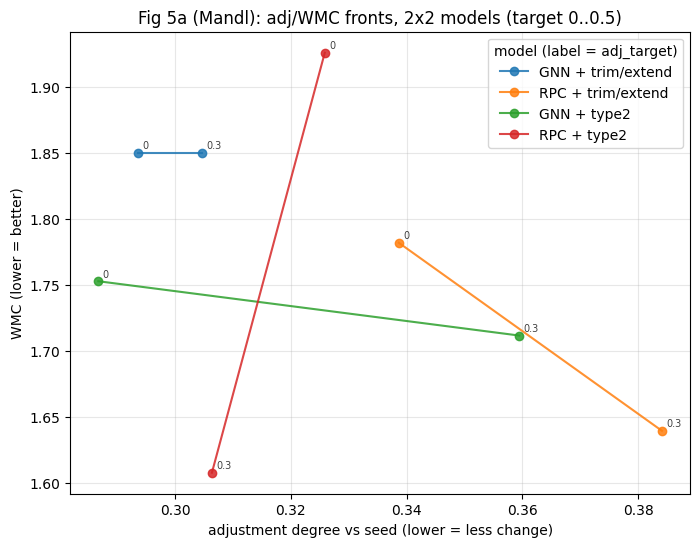

E2 Mandl alpha:   0%|          | 0/8 [00:00<?, ?it/s]

[Mandl_alpha0.0_s0_abl_GNN_trimextend] route_selection=uniform-random | bee split: heuristic_rebuild=2 local_endpoint_edit=0 path_mix_rebuild=0 construction_extend=0 extend_trim_edit=2 trim_only=0 trim_then_extend=0 (total=4)
[Mandl_alpha1.0_s0_abl_GNN_trimextend] route_selection=uniform-random | bee split: heuristic_rebuild=2 local_endpoint_edit=0 path_mix_rebuild=0 construction_extend=0 extend_trim_edit=2 trim_only=0 trim_then_extend=0 (total=4)
[Mandl_alpha0.0_s0_abl_RPC_trimextend] route_selection=uniform-random | bee split: heuristic_rebuild=0 local_endpoint_edit=0 path_mix_rebuild=2 construction_extend=0 extend_trim_edit=2 trim_only=0 trim_then_extend=0 (total=4)
[Mandl_alpha1.0_s0_abl_RPC_trimextend] route_selection=uniform-random | bee split: heuristic_rebuild=0 local_endpoint_edit=0 path_mix_rebuild=2 construction_extend=0 extend_trim_edit=2 trim_only=0 trim_then_extend=0 (total=4)
[Mandl_alpha0.0_s0_abl_GNN_type2] route_selection=uniform-random | bee split: heuristic_rebuild=

,city,model,alpha,ATT,RTT,WMC,adj_vs_seed,cost,d0,d1,d2,d_un,redun%
0,Mandl,GNN + trim/extend,0.0,23.3674,176.0,2.1026,0.6931,0.8889,39.8202,20.9377,16.7630,22.4791,6.2500
1,Mandl,GNN + trim/extend,1.0,11.1509,310.0,1.3341,0.5855,0.3379,81.0533,18.2402,0.7065,0.0000,24.1379
2,Mandl,RPC + trim/extend,0.0,21.8452,224.0,1.9941,0.5659,1.1313,32.6268,35.8382,19.4605,12.0745,21.0526
3,Mandl,RPC + trim/extend,1.0,11.2434,322.0,1.4156,0.5146,0.3407,78.9338,21.0662,0.0000,0.0000,25.0000
4,Mandl,GNN + type2,0.0,26.2633,172.0,2.2473,0.6230,0.8687,40.3982,9.5697,18.0475,31.9846,6.6667
5,Mandl,GNN + type2,1.0,11.0918,318.0,1.4141,0.5565,0.3361,82.2094,17.3410,0.4496,0.0000,15.3846
6,Mandl,RPC + type2,0.0,19.9011,188.0,2.0896,0.6767,0.9495,34.7463,50.9313,14.3224,0.0000,16.6667
7,Mandl,RPC + type2,1.0,11.0045,424.0,1.4275,0.5310,0.3335,88.8889,10.5973,0.5138,0.0000,41.1765


[paper] table (8 rows) -> D:\PythonProjects\connectpt\artifacts\paper_results\final_fig5b_attrtt_Mandl.csv
[paper] figure 'final_fig5b_attrtt_Mandl' shown inline (rebuild from CSV / route dump)


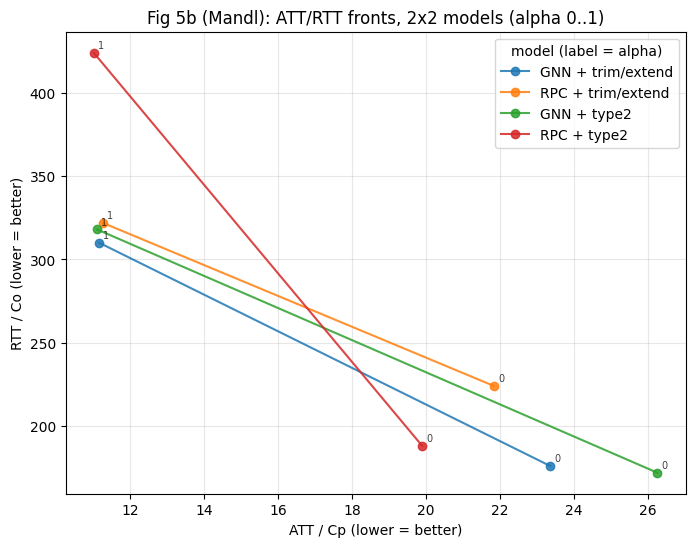

[sequential] Mandl pareto fronts complete & saved to paper_results
=== Mumford0: 2x2 ablation fronts ===


E2 Mumford0 adj_target:   0%|          | 0/8 [00:00<?, ?it/s]

[Mumford0_adj_target0.0_s0_abl_GNN_trimextend] route_selection=uniform-random | bee split: heuristic_rebuild=2 local_endpoint_edit=0 path_mix_rebuild=0 construction_extend=0 extend_trim_edit=2 trim_only=0 trim_then_extend=0 (total=4)
[Mumford0_adj_target0.3_s0_abl_GNN_trimextend] route_selection=uniform-random | bee split: heuristic_rebuild=2 local_endpoint_edit=0 path_mix_rebuild=0 construction_extend=0 extend_trim_edit=2 trim_only=0 trim_then_extend=0 (total=4)
[Mumford0_adj_target0.0_s0_abl_RPC_trimextend] route_selection=uniform-random | bee split: heuristic_rebuild=0 local_endpoint_edit=0 path_mix_rebuild=2 construction_extend=0 extend_trim_edit=2 trim_only=0 trim_then_extend=0 (total=4)
[Mumford0_adj_target0.3_s0_abl_RPC_trimextend] route_selection=uniform-random | bee split: heuristic_rebuild=0 local_endpoint_edit=0 path_mix_rebuild=2 construction_extend=0 extend_trim_edit=2 trim_only=0 trim_then_extend=0 (total=4)
[Mumford0_adj_target0.0_s0_abl_GNN_type2] route_selection=unifor

,city,model,adj_target,ATT,RTT,WMC,adj_vs_seed,cost,d0,d1,d2,d_un,redun%
0,Mumford0,GNN + trim/extend,0.0,25.1139,406.0,8.3763,0.2130,2.4565,22.1943,37.0382,20.1865,20.5810,26.8293
1,Mumford0,GNN + trim/extend,0.3,26.6482,426.0,9.1736,0.3581,2.1987,26.4233,44.3944,23.3341,5.8481,26.1905
2,Mumford0,RPC + trim/extend,0.0,22.4870,478.0,7.5746,0.1169,3.5838,26.2217,34.2705,7.7420,31.7658,36.9565
3,Mumford0,RPC + trim/extend,0.3,20.8215,604.0,7.5579,0.3186,3.0911,34.3348,41.8751,11.4332,12.3568,38.9831
4,Mumford0,GNN + type2,0.0,34.0217,300.0,10.8021,0.1706,3.5535,18.9940,17.0184,16.1766,47.8110,29.0323
5,Mumford0,GNN + type2,0.3,26.8643,378.0,9.7266,0.3812,1.2115,22.7496,60.7786,16.4718,0.0000,21.0526
6,Mumford0,RPC + type2,0.0,25.6013,368.0,8.5340,0.0323,4.2657,27.3293,17.0651,3.3639,52.2416,38.8889
7,Mumford0,RPC + type2,0.3,21.3178,452.0,6.6851,0.2990,2.9142,30.3601,30.5208,14.0314,25.0877,29.1667


[paper] table (8 rows) -> D:\PythonProjects\connectpt\artifacts\paper_results\final_fig5a_adj_Mumford0.csv
[paper] figure 'final_fig5a_adj_Mumford0' shown inline (rebuild from CSV / route dump)


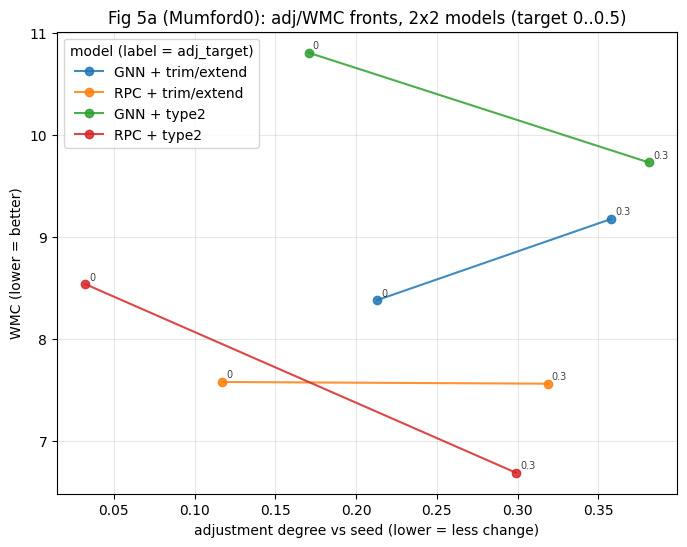

E2 Mumford0 alpha:   0%|          | 0/8 [00:00<?, ?it/s]

[Mumford0_alpha0.0_s0_abl_GNN_trimextend] route_selection=uniform-random | bee split: heuristic_rebuild=2 local_endpoint_edit=0 path_mix_rebuild=0 construction_extend=0 extend_trim_edit=2 trim_only=0 trim_then_extend=0 (total=4)
[Mumford0_alpha1.0_s0_abl_GNN_trimextend] route_selection=uniform-random | bee split: heuristic_rebuild=2 local_endpoint_edit=0 path_mix_rebuild=0 construction_extend=0 extend_trim_edit=2 trim_only=0 trim_then_extend=0 (total=4)
[Mumford0_alpha0.0_s0_abl_RPC_trimextend] route_selection=uniform-random | bee split: heuristic_rebuild=0 local_endpoint_edit=0 path_mix_rebuild=2 construction_extend=0 extend_trim_edit=2 trim_only=0 trim_then_extend=0 (total=4)
[Mumford0_alpha1.0_s0_abl_RPC_trimextend] route_selection=uniform-random | bee split: heuristic_rebuild=0 local_endpoint_edit=0 path_mix_rebuild=2 construction_extend=0 extend_trim_edit=2 trim_only=0 trim_then_extend=0 (total=4)
[Mumford0_alpha0.0_s0_abl_GNN_type2] route_selection=uniform-random | bee split: heu

,city,model,alpha,ATT,RTT,WMC,adj_vs_seed,cost,d0,d1,d2,d_un,redun%
0,Mumford0,GNN + trim/extend,0.0,37.2145,304.0,11.4356,0.9167,0.9744,18.4504,30.1263,20.7505,30.6728,3.2258
1,Mumford0,GNN + trim/extend,1.0,18.6370,634.0,6.5596,0.7724,0.7168,35.4366,54.6206,9.9427,0.0000,32.3077
2,Mumford0,RPC + trim/extend,0.0,22.0520,478.0,7.9633,0.7500,1.5321,26.6863,49.5470,19.6516,4.1150,17.3913
3,Mumford0,RPC + trim/extend,1.0,17.0709,862.0,6.2670,0.8125,0.6566,46.3380,49.0998,4.5622,0.0000,34.4444
4,Mumford0,GNN + type2,0.0,30.1272,312.0,9.9745,0.5373,1.0000,18.2780,38.1225,26.1194,17.4801,9.3750
5,Mumford0,GNN + type2,1.0,21.2282,440.0,7.2665,0.6431,0.8165,25.7190,51.8383,22.4427,0.0000,20.4545
6,Mumford0,RPC + type2,0.0,22.1627,412.0,7.3809,0.3884,2.4757,26.9815,33.0459,24.6990,15.2736,22.7273
7,Mumford0,RPC + type2,1.0,19.4552,810.0,6.8864,0.6256,0.7483,42.0359,43.7632,13.4937,0.7073,39.7727


[paper] table (8 rows) -> D:\PythonProjects\connectpt\artifacts\paper_results\final_fig5b_attrtt_Mumford0.csv
[paper] figure 'final_fig5b_attrtt_Mumford0' shown inline (rebuild from CSV / route dump)


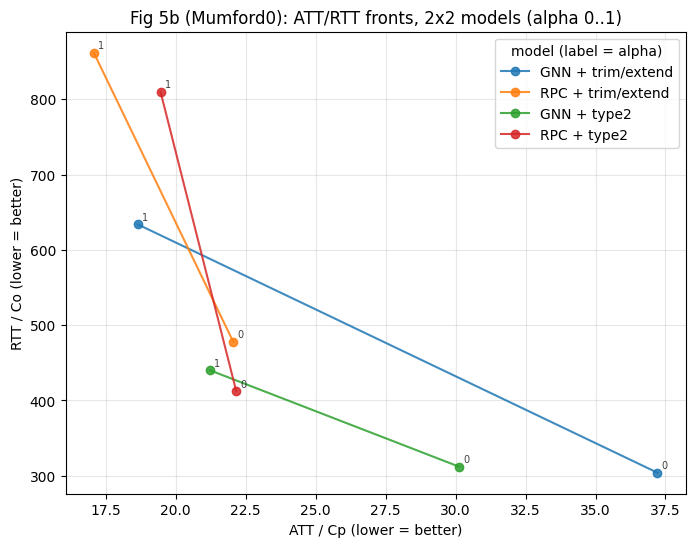

[sequential] Mumford0 pareto fronts complete & saved to paper_results
=== Mumford1: 2x2 ablation fronts ===


E2 Mumford1 adj_target:   0%|          | 0/8 [00:00<?, ?it/s]

[Mumford1_adj_target0.0_s0_abl_GNN_trimextend] route_selection=uniform-random | bee split: heuristic_rebuild=2 local_endpoint_edit=0 path_mix_rebuild=0 construction_extend=0 extend_trim_edit=2 trim_only=0 trim_then_extend=0 (total=4)
[Mumford1_adj_target0.3_s0_abl_GNN_trimextend] route_selection=uniform-random | bee split: heuristic_rebuild=2 local_endpoint_edit=0 path_mix_rebuild=0 construction_extend=0 extend_trim_edit=2 trim_only=0 trim_then_extend=0 (total=4)
[Mumford1_adj_target0.0_s0_abl_RPC_trimextend] route_selection=uniform-random | bee split: heuristic_rebuild=0 local_endpoint_edit=0 path_mix_rebuild=2 construction_extend=0 extend_trim_edit=2 trim_only=0 trim_then_extend=0 (total=4)
[Mumford1_adj_target0.3_s0_abl_RPC_trimextend] route_selection=uniform-random | bee split: heuristic_rebuild=0 local_endpoint_edit=0 path_mix_rebuild=2 construction_extend=0 extend_trim_edit=2 trim_only=0 trim_then_extend=0 (total=4)
[Mumford1_adj_target0.0_s0_abl_GNN_type2] route_selection=unifor

,city,model,adj_target,ATT,RTT,WMC,adj_vs_seed,cost,d0,d1,d2,d_un,redun%
0,Mumford1,GNN + trim/extend,0.0,44.5687,1544.0,15.8932,0.1016,2.3394,17.9221,34.5670,36.1479,11.3630,41.6667
1,Mumford1,GNN + trim/extend,0.3,36.4177,1324.0,12.3368,0.2878,2.0061,17.7253,35.7980,31.6722,14.8045,29.4964
2,Mumford1,RPC + trim/extend,0.0,33.9699,1692.0,11.6290,0.0255,3.8897,19.6608,36.5284,22.6932,21.1176,44.6541
3,Mumford1,RPC + trim/extend,0.3,29.7082,1754.0,10.1326,0.2710,3.4412,21.7239,43.1758,24.8327,10.2675,36.9048
4,Mumford1,GNN + type2,0.0,38.0741,1476.0,13.0257,0.0817,3.1587,18.3042,38.1768,27.5054,16.0136,38.7324
5,Mumford1,GNN + type2,0.3,33.7215,1356.0,10.8409,0.2942,2.0545,17.8515,34.1024,30.4070,17.6392,22.7941
6,Mumford1,RPC + type2,0.0,33.6251,1632.0,11.6987,0.0606,3.7988,21.4856,36.9978,19.7397,21.7769,40.6452
7,Mumford1,RPC + type2,0.3,29.8387,1620.0,9.8265,0.2133,3.3769,20.3892,38.4956,25.8809,15.2344,35.2201


[paper] table (8 rows) -> D:\PythonProjects\connectpt\artifacts\paper_results\final_fig5a_adj_Mumford1.csv
[paper] figure 'final_fig5a_adj_Mumford1' shown inline (rebuild from CSV / route dump)


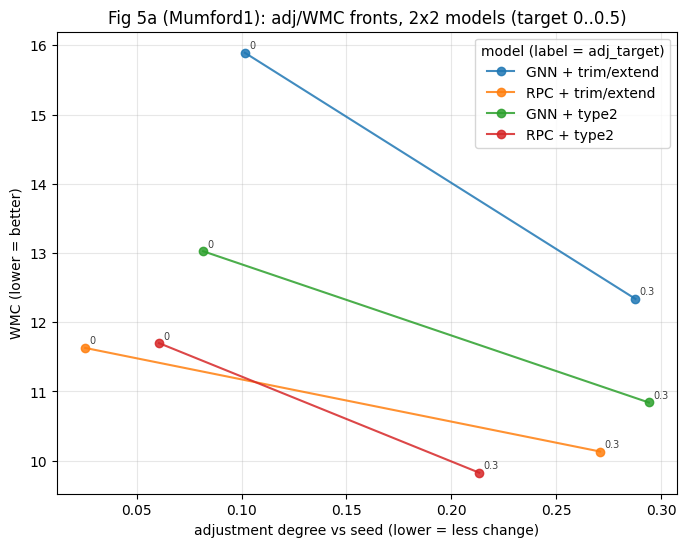

E2 Mumford1 alpha:   0%|          | 0/8 [00:00<?, ?it/s]

[Mumford1_alpha0.0_s0_abl_GNN_trimextend] route_selection=uniform-random | bee split: heuristic_rebuild=2 local_endpoint_edit=0 path_mix_rebuild=0 construction_extend=0 extend_trim_edit=2 trim_only=0 trim_then_extend=0 (total=4)
[Mumford1_alpha1.0_s0_abl_GNN_trimextend] route_selection=uniform-random | bee split: heuristic_rebuild=2 local_endpoint_edit=0 path_mix_rebuild=0 construction_extend=0 extend_trim_edit=2 trim_only=0 trim_then_extend=0 (total=4)
[Mumford1_alpha0.0_s0_abl_RPC_trimextend] route_selection=uniform-random | bee split: heuristic_rebuild=0 local_endpoint_edit=0 path_mix_rebuild=2 construction_extend=0 extend_trim_edit=2 trim_only=0 trim_then_extend=0 (total=4)
[Mumford1_alpha1.0_s0_abl_RPC_trimextend] route_selection=uniform-random | bee split: heuristic_rebuild=0 local_endpoint_edit=0 path_mix_rebuild=2 construction_extend=0 extend_trim_edit=2 trim_only=0 trim_then_extend=0 (total=4)
[Mumford1_alpha0.0_s0_abl_GNN_type2] route_selection=uniform-random | bee split: heu

,city,model,alpha,ATT,RTT,WMC,adj_vs_seed,cost,d0,d1,d2,d_un,redun%
0,Mumford1,GNN + trim/extend,0.0,33.6382,1198.0,11.1956,0.5667,1.8152,19.0445,39.5380,28.5395,12.8779,20.0000
1,Mumford1,GNN + trim/extend,1.0,26.4644,1828.0,9.2184,0.5454,0.6015,28.4004,54.4137,16.2483,0.9376,28.7234
2,Mumford1,RPC + trim/extend,0.0,29.2636,1616.0,9.9978,0.5548,3.0913,22.4648,45.0604,26.4888,5.9860,35.5828
3,Mumford1,RPC + trim/extend,1.0,26.4147,2210.0,9.2995,0.6062,0.6003,29.7040,53.0576,16.1720,1.0664,41.2844
4,Mumford1,GNN + type2,0.0,34.3934,1162.0,11.2610,0.6133,1.7606,19.3565,37.6659,30.3525,12.6251,20.7407
5,Mumford1,GNN + type2,1.0,27.2011,1470.0,9.2602,0.5347,0.6182,25.9115,48.6105,22.6538,2.8243,16.0256
6,Mumford1,RPC + type2,0.0,29.8387,1620.0,9.8265,0.2133,3.3769,20.3892,38.4956,25.8809,15.2344,35.2201
7,Mumford1,RPC + type2,1.0,26.4249,2194.0,9.3058,0.5367,0.6006,29.9319,52.6812,15.6710,1.7158,42.4107


[paper] table (8 rows) -> D:\PythonProjects\connectpt\artifacts\paper_results\final_fig5b_attrtt_Mumford1.csv
[paper] figure 'final_fig5b_attrtt_Mumford1' shown inline (rebuild from CSV / route dump)


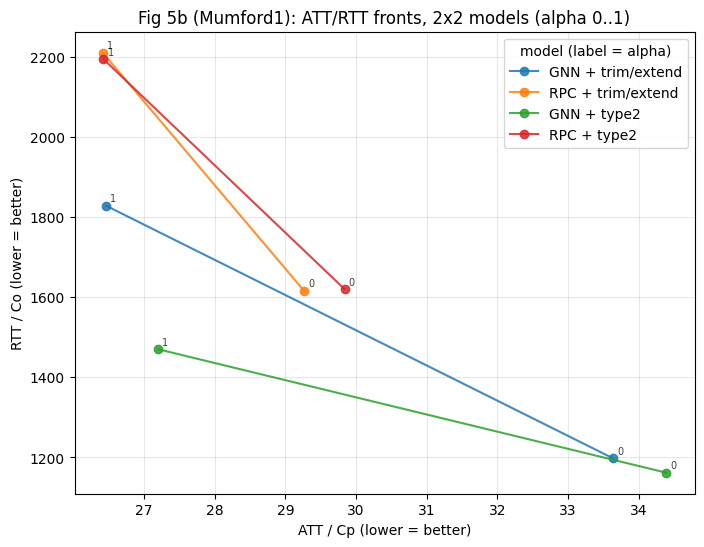

[sequential] Mumford1 pareto fronts complete & saved to paper_results


In [ ]:
def _city_ctx(city):
    spec = next(s for s in BENCHMARK_SPECS if s["city"] == city)
    tensors, init = load_benchmark_graph(spec)
    s = algo_settings(city)
    return dict(city=city, spec=spec, tensors=tensors, init=init,
                nb=int(s["bco_bees"]), settings=s)


def _run_abl(ctx, construct, edit, *, adj_target=None, alpha=None, tag="", seed=None,
             bco_iterations=None):
    """One 2x2 run for a city. alpha -> ATT/RTT weights; adj_target -> adj cap."""
    var = abl_variant(construct, edit, ctx["nb"])
    if alpha is not None:
        weights = {"demand_time_weight": alpha, "route_time_weight": 1.0 - alpha,
                   "median_connectivity_weight": 0.0}
    else:
        weights = OUR_WEIGHTS
    spec = ctx["spec"]
    cfg = build_bco_cfg(
        run_name=f"{ctx['city']}_{tag}_{var['run_name']}",
        n_routes=spec["n_routes"], min_route_len=spec["min_route_len"],
        max_route_len=spec["max_route_len"], use_neural_bees=var["use_neural_bees"],
        n_bees=ctx["nb"], n_type1_bees=var["n_type1_bees"], n_type2_bees=var["n_type2_bees"],
        n_type4_bees=0, n_type5_bees=var["n_type5_bees"], n_type6_bees=0, n_type7_bees=0,
        **ctx["settings"].get("bco_args", {}), **weights)
    bco_cfg_set(cfg, n_iterations=int(E2_BCO_ITERATIONS if bco_iterations is None else bco_iterations))
    if adj_target is not None:
        bco_cfg_set(cfg, adjustment_degree_weight=float(ADJ_FIXED_W),
                    adjustment_degree_objective="cap",
                    adjustment_degree_target=float(adj_target),
                    adjustment_degree_gap=ADJ_GAP, adjustment_degree_mode=ADJ_MODE)
    if seed is not None:
        _set_cfg_value(cfg, "experiment.seed", int(seed))
    res = run_bco(cfg, ctx["init"], tensors=ctx["tensors"], run_name_scope=f"{ctx['city']}_")
    return res[3], res[1]


def _abl_row(ctx, model, sweep_name, sweep_val, routes, metrics):
    rt = as_route_tensor(routes)
    return {"city": ctx["city"], "model": model, sweep_name: float(sweep_val),
            **_full_metrics(metrics, rt, ctx["init"])}


def _plot_models(df, x, y, sweep, xlabel, ylabel, title, save_name=None):
    """One front per 2x2 model; each point annotated with its sweep value
    (adjustment-degree target or alpha). Optionally saved to paper_results."""
    fig, ax = plt.subplots(figsize=(8, 6))
    for model in ABL_MODELS:
        sub = df[df["model"] == model].sort_values(sweep)
        if sub.empty:
            continue
        ax.plot(sub[x], sub[y], marker="o", label=model, alpha=0.85)
        for _, r in sub.iterrows():
            ax.annotate(f"{r[sweep]:g}", (r[x], r[y]), fontsize=7, alpha=0.75,
                        xytext=(3, 3), textcoords="offset points")
    ax.set_xlabel(xlabel); ax.set_ylabel(ylabel); ax.set_title(title)
    ax.legend(title=f"model (label = {sweep})"); ax.grid(alpha=0.3)
    if save_name:
        save_paper_fig(fig, save_name)
    plt.show(); plt.close(fig)


def _sweep_models(ctx, sweep_name, grid, **abl_kw):
    # one progress bar over every BCO run in this sweep (models x grid x seeds),
    # so the bar shows total count + ETA for the whole sweep.
    combos = [(m, v, sd) for m in ABL_MODELS for v in grid for sd in SEEDS]
    agg = {}
    for model, val, sd in tqdm(combos, desc=f"E2 {ctx['city']} {sweep_name}", leave=True):
        c, e = model.split(" + ")
        try:
            r, m = _run_abl(ctx, c, e, tag=f"{sweep_name}{val}_s{sd}",
                            seed=sd, **{sweep_name: val}, **abl_kw)
            agg.setdefault((model, val), []).append(
                _abl_row(ctx, model, sweep_name, val, r, m))
        except Exception as exc:
            print(f"  {ctx['city']}/{model} {sweep_name}={val} seed={sd} FAILED: {exc}")
    rows = [(_mean_over_seeds(sr) if len(sr) > 1 else sr[0]) for sr in agg.values()]
    return pd.DataFrame(rows)


ADJ_DF_BY_CITY, ALPHA_DF_BY_CITY = {}, {}
for _city in E2_CITIES:
    print(f"=== {_city}: 2x2 ablation fronts ===")
    _ctx = _city_ctx(_city)
    _sfx = "_smoke" if SMOKE else ""

    adj_df_c = _sweep_models(_ctx, "adj_target", ADJ_TARGET_GRID)
    if not adj_df_c.empty:
        display(adj_df_c.round(4))
        save_paper_table(adj_df_c.round(4), f"final_fig5a_adj_{_city}{_sfx}")
        _plot_models(adj_df_c, "adj_vs_seed", "WMC", "adj_target",
                     "adjustment degree vs seed (lower = less change)",
                     "WMC (lower = better)",
                     f"Fig 5a ({_city}): adj/WMC fronts, 2x2 models (target 0..0.5)",
                     save_name=f"final_fig5a_adj_{_city}{_sfx}")

    alpha_df_c = _sweep_models(_ctx, "alpha", ALPHA_GRID)
    if not alpha_df_c.empty:
        display(alpha_df_c.round(4))
        save_paper_table(alpha_df_c.round(4), f"final_fig5b_attrtt_{_city}{_sfx}")
        _plot_models(alpha_df_c, "ATT", "RTT", "alpha",
                     "ATT / Cp (lower = better)", "RTT / Co (lower = better)",
                     f"Fig 5b ({_city}): ATT/RTT fronts, 2x2 models (alpha 0..1)",
                     save_name=f"final_fig5b_attrtt_{_city}{_sfx}")

    ADJ_DF_BY_CITY[_city] = adj_df_c
    ALPHA_DF_BY_CITY[_city] = alpha_df_c
    print(f"[sequential] {_city} pareto fronts complete & saved to paper_results")

# back-compat single-city handles (first city) for downstream cells
PARETO_CITY = CITIES[0]
adj_df = ADJ_DF_BY_CITY.get(PARETO_CITY, pd.DataFrame())
alpha_df = ALPHA_DF_BY_CITY.get(PARETO_CITY, pd.DataFrame())


## E3 - minimal intervention: our model under different adj targets

Re-runs **our model (GNN + trim/extend)** with the adjustment-degree cap set to several targets and shows seed -> edited route figures per target -- how much the network changes as the cap tightens. (Previously E3 used the no-adj main run; now it sweeps the target.)

E3 Mandl adj targets:   0%|          | 0/2 [00:00<?, ?it/s]

[Mandl_e3_0.0_abl_GNN_trimextend] route_selection=uniform-random | bee split: heuristic_rebuild=2 local_endpoint_edit=0 path_mix_rebuild=0 construction_extend=0 extend_trim_edit=2 trim_only=0 trim_then_extend=0 (total=4)
[Mandl_e3_0.3_abl_GNN_trimextend] route_selection=uniform-random | bee split: heuristic_rebuild=2 local_endpoint_edit=0 path_mix_rebuild=0 construction_extend=0 extend_trim_edit=2 trim_only=0 trim_then_extend=0 (total=4)


,target,ATT,RTT,WMC,adj_vs_seed,cost,d0,d1,d2,d_un,redun%
0,0.0,15.6069,234.0,1.8503,0.2937,1.1818,58.6384,40.0128,1.3487,0.0000,23.8095
1,0.3,15.8927,230.0,1.8503,0.3046,1.1616,57.1612,37.6365,4.8170,0.3854,20.0000


[paper] table (2 rows) -> D:\PythonProjects\connectpt\artifacts\paper_results\final_e3_targets_Mandl.csv
[paper] route dump (3 sets) -> D:\PythonProjects\connectpt\artifacts\paper_results\final_e3_targets_Mandl_routes.pt
[paper] figure 'final_e3_targets_Mandl' shown inline (rebuild from CSV / route dump)


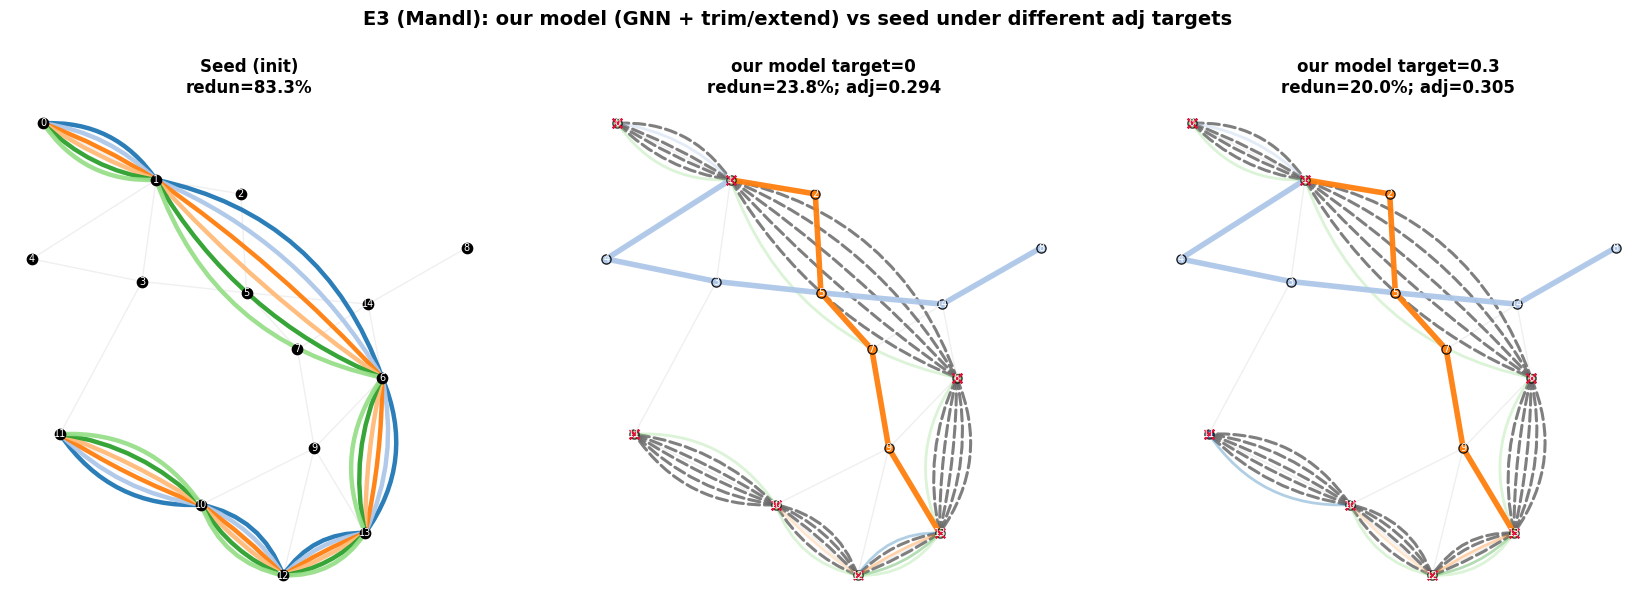

In [ ]:
E3_CITY = CITIES[0]
e3_spec = next(s for s in BENCHMARK_SPECS if s["city"] == E3_CITY)
e3_tensors, e3_init = load_benchmark_graph(e3_spec)
_e3_ctx = _city_ctx(E3_CITY)

# Our model = GNN + trim/extend, re-run under several adjustment-degree targets
# to show how the edited network deviates from the seed as the cap tightens.
e3_rows = []
e3_routes = {"Seed (init)": as_route_tensor(e3_init)}
for _t in tqdm(E3_TARGETS, desc=f"E3 {E3_CITY} adj targets"):
    try:
        _r, _m = _run_abl(_e3_ctx, "GNN", "trim/extend", adj_target=_t, tag=f"e3_{_t}",
                            bco_iterations=E3_BCO_ITERATIONS)
        rt = as_route_tensor(_r)
        e3_routes[f"target={_t:g}"] = rt
        e3_rows.append({"target": _t, **_full_metrics(_m, rt, e3_init)})
    except Exception as exc:
        print(f"E3 target={_t} FAILED: {exc}")
e3_df = pd.DataFrame(e3_rows).round(4)
display(e3_df)
save_paper_table(e3_df, f"final_e3_targets_{E3_CITY}" + ("_smoke" if SMOKE else ""))
save_paper_routes(f"final_e3_targets_{E3_CITY}" + ("_smoke" if SMOKE else ""),
                  e3_routes, e3_tensors["node_locs"], e3_tensors["street_adj"],
                  meta={"city": E3_CITY, "targets": E3_TARGETS})

labels = list(e3_routes)
fig, axes = plt.subplots(1, len(labels), figsize=(7 * len(labels), 7), squeeze=False)
_sr = as_route_tensor(e3_init); _sr = _sr[0] if _sr.ndim == 3 else _sr
for ax, lab in zip(axes[0], labels):
    rt = e3_routes[lab]; rr = rt[0] if rt.ndim == 3 else rt
    try:
        if lab.startswith("Seed"):
            route_plots.plot_plain_route_set(ax, rr, e3_tensors["node_locs"],
                e3_tensors["street_adj"], title=lab,
                subtitle=f"redun={redundancy_pct(rt):.1f}%")
        else:
            route_plots.plot_route_diff(ax, rr, _sr, e3_tensors["node_locs"],
                e3_tensors["street_adj"], title=f"our model {lab}",
                subtitle=f"redun={redundancy_pct(rt):.1f}%; adj={adj_vs_init(rt, e3_init):.3f}")
    except Exception as exc:
        ax.set_title(f"{lab}: plot failed ({exc})")
fig.suptitle(f"E3 ({E3_CITY}): our model (GNN + trim/extend) vs seed under different adj targets",
             fontsize=14, fontweight="bold")
save_paper_fig(fig, f"final_e3_targets_{E3_CITY}" + ("_smoke" if SMOKE else ""))
plt.show(); plt.close(fig)


## E4 - Convergence (cost vs iteration, reused from E1)

No re-run: plots the per-method cost histories captured during the **E1** live runs (`CITY_CONV`) for one representative city.

[paper] figure 'final_convergence_Mandl' shown inline (rebuild from CSV / route dump)


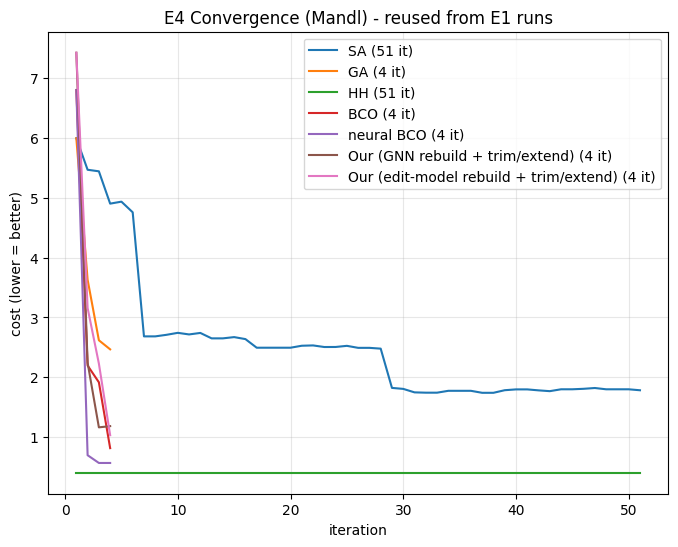

[paper] table (51 rows) -> D:\PythonProjects\connectpt\artifacts\paper_results\final_convergence_Mandl.csv
E4 reuses E1 cost histories (no re-run): ['SA', 'GA', 'HH', 'BCO', 'neural BCO', 'Our (GNN rebuild + trim/extend)', 'Our (edit-model rebuild + trim/extend)']


In [ ]:
CONV_CITY = CITIES[0]
conv = CITY_CONV.get(CONV_CITY, {})
if not conv:
    print(f"no convergence history for {CONV_CITY}; run E1 first")
else:
    fig, ax = plt.subplots(figsize=(8, 6))
    for name, h in conv.items():
        if h:
            ax.plot(range(1, len(h) + 1), h, label=f"{name} ({len(h)} it)")
    ax.set_xlabel("iteration"); ax.set_ylabel("cost (lower = better)")
    ax.set_title(f"E4 Convergence ({CONV_CITY}) - reused from E1 runs")
    ax.legend(); ax.grid(alpha=0.3)
    save_paper_fig(fig, f"final_convergence_{CONV_CITY}" + ("_smoke" if SMOKE else ""))
    plt.show(); plt.close(fig)
    conv_df = pd.DataFrame({k: pd.Series(v) for k, v in conv.items()})
    save_paper_table(conv_df, f"final_convergence_{CONV_CITY}" + ("_smoke" if SMOKE else ""))
    print(f"E4 reuses E1 cost histories (no re-run): {list(conv)}")

## Next steps / TODO
- Swap `OUR_MODEL_PATH` to a route+conn+**adj**-trained model when ready.
- Flip `SMOKE=False` for the full Mumford0-3 run (3 seeds).
- E2: tune the trim/extend bee split if the front does not separate.

## E5 - Paper Fig 3 (Cp x Co Pareto) + Fig 5 (RL ablation)

Reproduces the paper's canonical figures via `run_alpha_pareto_sweep` + `plot_alpha_pareto_grid` (x = Cp = ATT passenger, y = Co = RTT operator), sweeping alpha 0->1.

- **Fig 3**: Cp x Co trade-off front per method.
- **Fig 5 (RL ablation)**: our **trained** standalone edit policy vs the same architecture **untrained** (`random_policy=True`) -- the analog of the paper's NEA vs RC-EA, isolating the value of training from the structure alone.

[paper] figure 'final_fig3_cpco_Mandl' shown inline (rebuild from CSV / route dump)


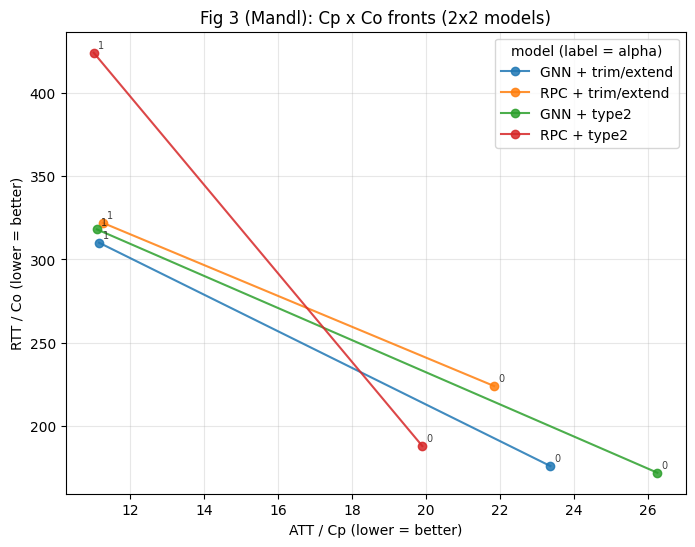

[paper] figure 'final_fig5_gnn_vs_rpc_Mandl' shown inline (rebuild from CSV / route dump)


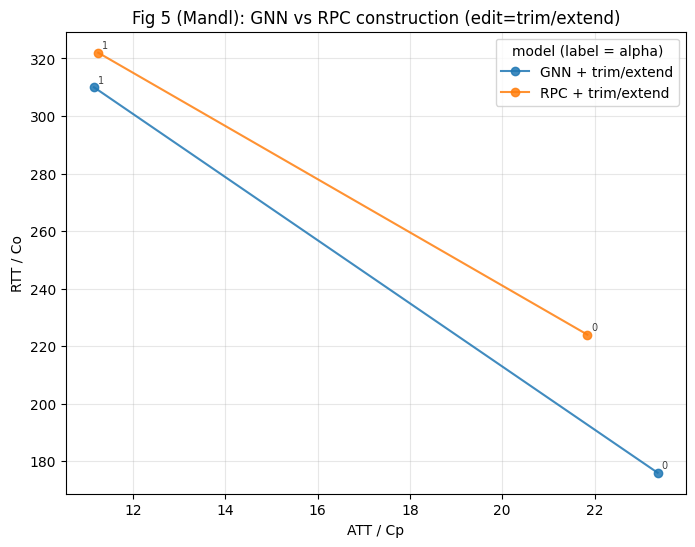

[paper] figure 'final_fig4_trimext_vs_type2_Mandl' shown inline (rebuild from CSV / route dump)


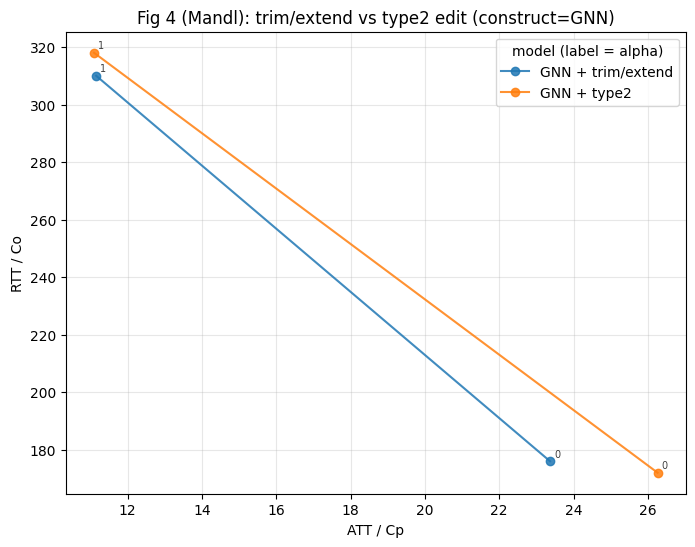

[paper] figure 'final_fig3_cpco_Mumford0' shown inline (rebuild from CSV / route dump)


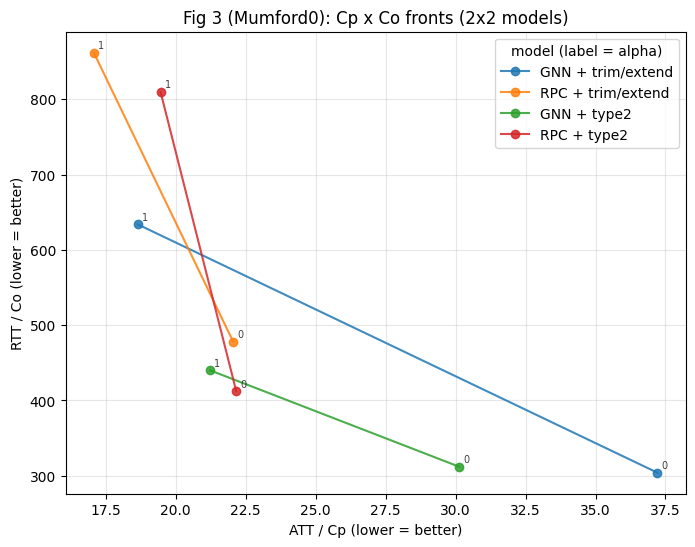

[paper] figure 'final_fig5_gnn_vs_rpc_Mumford0' shown inline (rebuild from CSV / route dump)


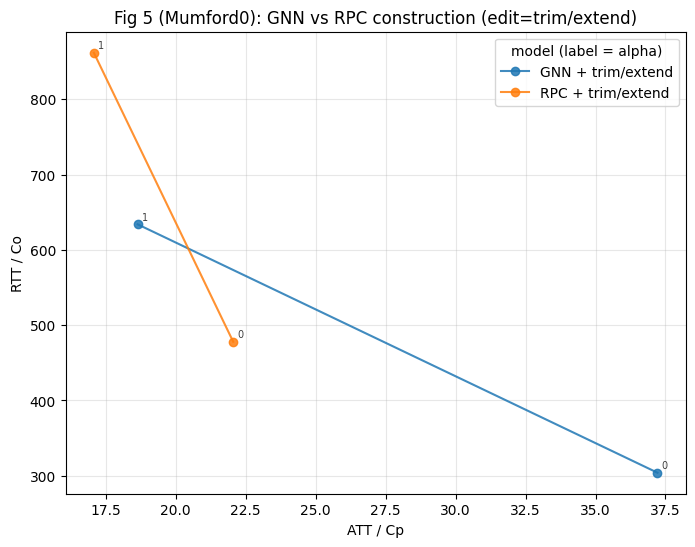

[paper] figure 'final_fig4_trimext_vs_type2_Mumford0' shown inline (rebuild from CSV / route dump)


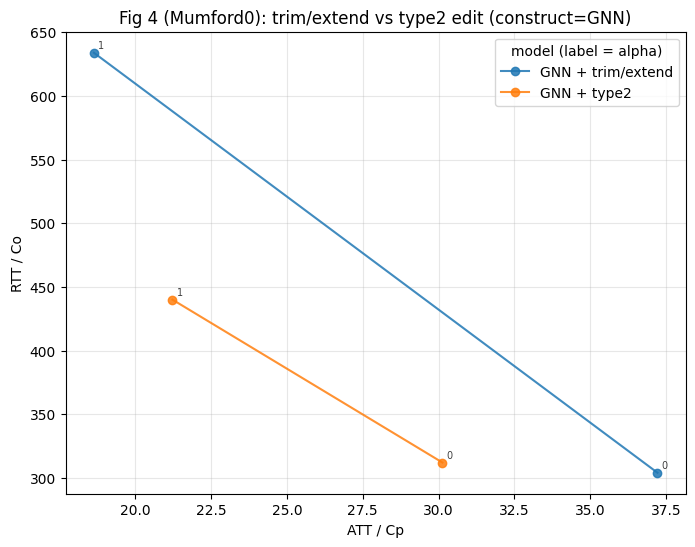

[paper] figure 'final_fig3_cpco_Mumford1' shown inline (rebuild from CSV / route dump)


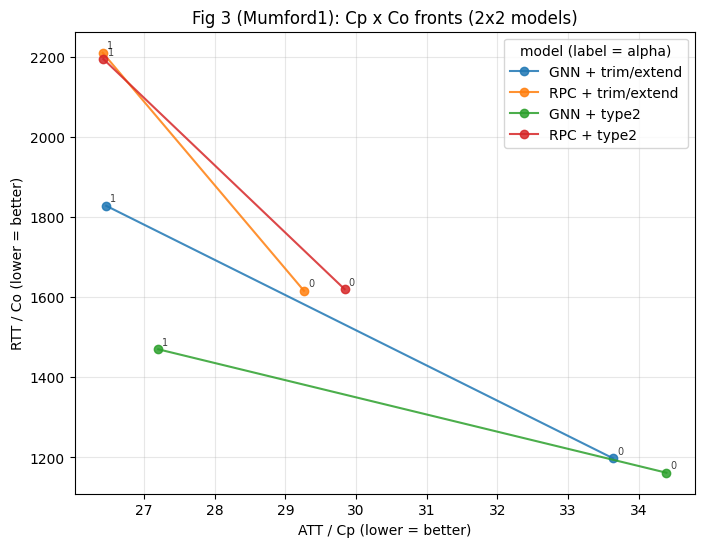

[paper] figure 'final_fig5_gnn_vs_rpc_Mumford1' shown inline (rebuild from CSV / route dump)


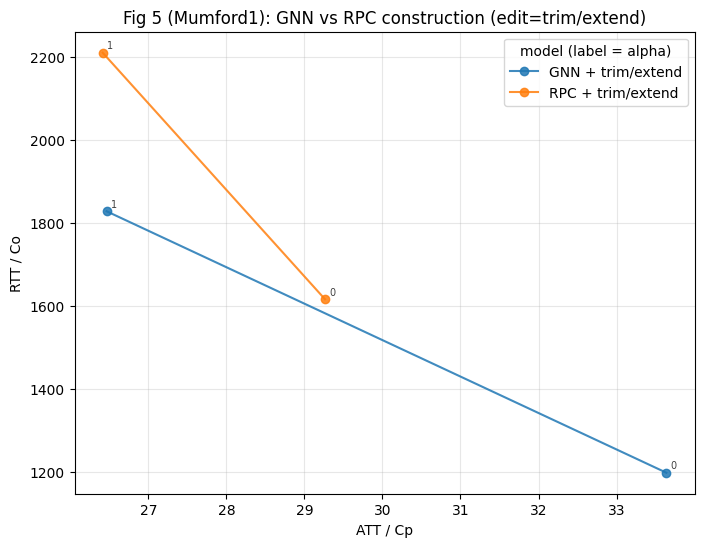

[paper] figure 'final_fig4_trimext_vs_type2_Mumford1' shown inline (rebuild from CSV / route dump)


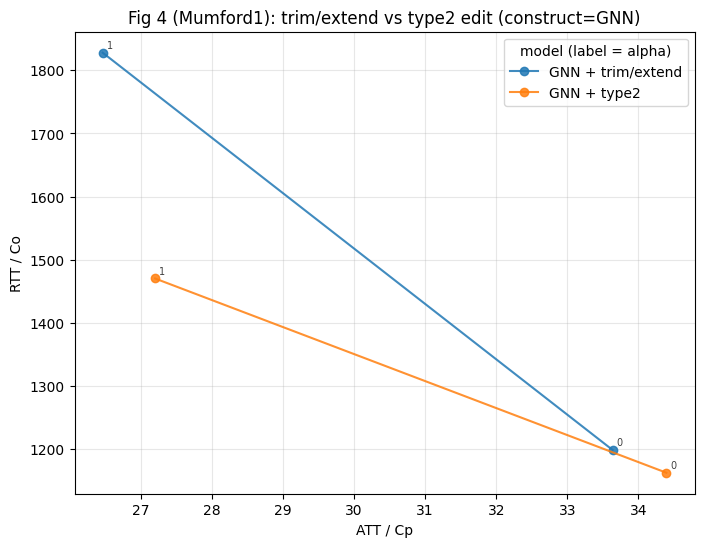

our model = 'GNN + trim/extend' (neural NBCO rebuild + our trim/extend edit bee)


In [ ]:
# Reuses ALPHA_DF_BY_CITY from E2 (4 models x alpha grid, per city).
# NOTE: if re-running the E2 alpha sweep is too slow / unstable, there are
# pre-computed alpha fronts in artifacts/results/final/: benchmark_alpha_rows.csv
# (all methods, ATT/RTT/cost per alpha) and b_pareto_ablation.csv (the same 2x2
# GNN/RPC x type2/trim-extend models on Mumford0). They lack WMC/adj/routes, but
# the Cp x Co (ATT x RTT) fronts can be plotted straight from them.
if "ALPHA_DF_BY_CITY" not in globals() or not ALPHA_DF_BY_CITY:
    raise RuntimeError("Run the E2 cell first (it computes ALPHA_DF_BY_CITY).")

for _city, _adf in ALPHA_DF_BY_CITY.items():
    if _adf.empty:
        continue
    _sfx = "_smoke" if SMOKE else ""
    # Fig 3: all four 2x2 models on Cp x Co; points labelled with alpha.
    _plot_models(_adf, "ATT", "RTT", "alpha",
                 "ATT / Cp (lower = better)", "RTT / Co (lower = better)",
                 f"Fig 3 ({_city}): Cp x Co fronts (2x2 models)",
                 save_name=f"final_fig3_cpco_{_city}{_sfx}")
    # Fig 5: GNN vs RPC construction (edit fixed = trim/extend) -> GNN contribution.
    _plot_models(_adf[_adf["model"].isin(["GNN + trim/extend", "RPC + trim/extend"])],
                 "ATT", "RTT", "alpha", "ATT / Cp", "RTT / Co",
                 f"Fig 5 ({_city}): GNN vs RPC construction (edit=trim/extend)",
                 save_name=f"final_fig5_gnn_vs_rpc_{_city}{_sfx}")
    # Fig 4: trim/extend vs type2 edit (construct fixed = GNN) -> our edit-bee contribution.
    _plot_models(_adf[_adf["model"].isin(["GNN + trim/extend", "GNN + type2"])],
                 "ATT", "RTT", "alpha", "ATT / Cp", "RTT / Co",
                 f"Fig 4 ({_city}): trim/extend vs type2 edit (construct=GNN)",
                 save_name=f"final_fig4_trimext_vs_type2_{_city}{_sfx}")

print("our model = 'GNN + trim/extend' (neural NBCO rebuild + our trim/extend edit bee)")


## E6 - redundancy-tier stress test (Mumford1, lc_redundancy route-gen)

For Mumford1 we build the **initial network with the lc_redundancy pipeline**: a
clean route set from the LC construction generator (`run_lc`) is corrupted with
per-tier copy-redundancy injection (`copy_full / copy_boundary / copy_mixed /
covered_dup`, plus the clean `lc_clean` baseline) - the exact tiers from
`lc_redundancy_route_conn_adj.ipynb`. Then **all baselines are re-run live**
(SA / GA / HH / NSGA-II / BCO / neural BCO) together with our model on each
tier, using the bounded non-smoke `E6_ALGO` profile from the config cell. Contract
= `eval/mumford1.yaml` (15 routes, len 10-30). adj/redun are measured vs each
tier's own seed network, so we can see which optimizer actually removes the
injected duplicates. Tables + route dumps go to `artifacts/paper_results/`.


In [ ]:
import random as _random

E6_EVAL_CFG = OmegaConf.load(CFG_DIR / "eval" / "mumford1.yaml")
E6_CITY = str(E6_EVAL_CFG.dataset.city)
E6_N_ROUTES = int(E6_EVAL_CFG.n_routes)
E6_MIN_LEN = int(E6_EVAL_CFG.min_route_len)
E6_MAX_LEN = int(E6_EVAL_CFG.max_route_len)
# bounded non-smoke budgets; defined in the PART 2 config cell and mirrored here for standalone reruns
E6_ALGO = dict(globals().get("E6_ALGO", dict(sa=500, hh=80, ga=10, ga_pop=12,
                                             nsgaii=(10, 8), bco=5, bco_bees=10)))
# tiers + configs mirror lc_redundancy_route_conn_adj.ipynb (TIER_CFG)
E6_D_UN_CAP = 10.0
_E6_KINDS = ("full_copy", "prefix_copy", "suffix_copy", "middle_copy")
E6_TIERS = ["copy_full", "copy_boundary", "copy_mixed", "covered_dup", "lc_clean"]
E6_TIER_CFG = {
    "lc_clean":      {"events": 0, "max_multiplicity": 1, "kinds": ()},
    "copy_full":     {"events": 3, "max_multiplicity": 3, "kinds": ("full_copy",)},
    "copy_boundary": {"events": 4, "max_multiplicity": 4, "kinds": ("prefix_copy", "suffix_copy")},
    "copy_mixed":    {"events": 6, "max_multiplicity": 5, "kinds": _E6_KINDS},
    "covered_dup":   {"events": 6, "max_multiplicity": 4, "kinds": _E6_KINDS,
                      "covered": True, "d_un_cap": E6_D_UN_CAP},
}


# ---- tier copy-injection helpers (ported from lc_redundancy notebook) ----
def _e6_nodes(route):
    return [int(n) for n in route.tolist() if int(n) >= 0]


def _e6_simple(nodes):
    return (E6_MIN_LEN <= len(nodes) <= E6_MAX_LEN and len(nodes) == len(set(nodes))
            and all(a != b for a, b in zip(nodes[:-1], nodes[1:])))


def _e6_redund(routes):
    c = Counter()
    for r in routes:
        ns = _e6_nodes(r)
        for a, b in zip(ns[:-1], ns[1:]):
            c[(min(a, b), max(a, b))] += 1
    t = sum(c.values())
    return 0.0 if t == 0 else (t - len(c)) / t


def _e6_uncovered(routes, demand, n):
    parent = list(range(n))
    def f(x):
        while parent[x] != x:
            parent[x] = parent[parent[x]]; x = parent[x]
        return x
    for r in routes:
        ns = _e6_nodes(r)
        for a, b in zip(ns[:-1], ns[1:]):
            ra, rb = f(a), f(b)
            if ra != rb:
                parent[ra] = rb
    D = demand if torch.is_tensor(demand) else torch.as_tensor(demand)
    tot = unc = 0.0
    for a, b in (D > 0).nonzero(as_tuple=False).tolist():
        if a == b:
            continue
        w = float(D[a, b]); tot += w
        if f(a) != f(b):
            unc += w
    return 0.0 if tot == 0 else 100.0 * unc / tot


def _e6_to_fixed(routes):
    t = as_route_tensor(routes).long()
    if t.ndim == 3:
        t = t[0]
    if t.shape[0] < E6_N_ROUTES:
        t = torch.cat([t, torch.full((E6_N_ROUTES - t.shape[0], t.shape[1]), -1, dtype=t.dtype, device=t.device)], 0)
    else:
        t = t[:E6_N_ROUTES]
    if t.shape[1] < E6_MAX_LEN:
        t = torch.cat([t, torch.full((t.shape[0], E6_MAX_LEN - t.shape[1]), -1, dtype=t.dtype, device=t.device)], 1)
    elif t.shape[1] > E6_MAX_LEN:
        t = t[:, :E6_MAX_LEN]
    return t


def _e6_candidate(routes, donor_idx, target_idx, kind, rng):
    donor = _e6_nodes(routes[donor_idx]); target = _e6_nodes(routes[target_idx])
    if not donor or not target:
        return None
    if kind == "full_copy":
        candidate = donor
    else:
        max_seg = min(len(donor), len(target), 6)
        if kind == "middle_copy":
            max_seg = min(max_seg, len(target) - 2)
        if max_seg < 2:
            return None
        seg = rng.randint(2, max_seg)
        if kind == "prefix_copy":
            candidate = donor[:seg] + target[seg:]
        elif kind == "suffix_copy":
            candidate = target[:-seg] + donor[-seg:]
        elif kind == "middle_copy":
            ds = rng.randint(0, len(donor) - seg); ts = rng.randint(1, len(target) - seg - 1)
            candidate = target[:ts] + donor[ds:ds + seg] + target[ts + seg:]
        else:
            raise ValueError(kind)
    if candidate == target or not _e6_simple(candidate):
        return None
    return candidate


def _e6_replace(routes, idx, nodes):
    routes[idx] = -1
    routes[idx, :len(nodes)] = torch.as_tensor(nodes, dtype=routes.dtype, device=routes.device)


def _e6_try(routes, kind, max_mult, rng, demand=None, n=None, cap=None, attempts=80):
    base = routes.clone()
    for _ in range(attempts):
        donor = rng.randrange(routes.shape[0])
        targets = [i for i in range(routes.shape[0]) if i != donor]; rng.shuffle(targets)
        wanted = rng.randint(1, min(max_mult - 1, len(targets)))
        mutated = base.clone(); cur = _e6_redund(mutated); touched = 0
        for ti in targets:
            cand = _e6_candidate(mutated, donor, ti, kind, rng)
            if cand is None:
                continue
            prop = mutated.clone(); _e6_replace(prop, ti, cand)
            if _e6_redund(prop) <= cur + 1e-12:
                continue
            if cap is not None and _e6_uncovered(prop, demand, n) > cap:
                continue
            mutated = prop; cur = _e6_redund(mutated); touched += 1
            if touched >= wanted:
                return mutated, touched
    return base, 0


def _e6_inject(routes, tier_cfg, rng, demand=None, n=None):
    routes = routes.clone()
    covered = bool(tier_cfg.get("covered", False))
    cap = float(tier_cfg.get("d_un_cap", 100.0)) if covered else None
    for _ in range(int(tier_cfg["events"])):
        kinds = list(tier_cfg["kinds"]); rng.shuffle(kinds)
        for kind in kinds:
            attempts = 160 if covered else 80
            prop, touched = _e6_try(routes, kind, int(tier_cfg["max_multiplicity"]),
                                    rng, demand=demand, n=n, cap=cap, attempts=attempts)
            if touched:
                routes = prop; break
    return routes


# ---- build the per-tier Mumford1 initial networks via the LC generator ----
e6_spec = {"city": E6_CITY, "n_routes": E6_N_ROUTES,
           "min_route_len": E6_MIN_LEN, "max_route_len": E6_MAX_LEN}
e6_tensors = load_benchmark_tensors(E6_CITY)
e6_n_nodes = e6_tensors["node_locs"].shape[0]
_e6_lc_cfg = build_lc_cfg(run_name="e6_lc_clean_base", n_routes=E6_N_ROUTES,
                          min_route_len=E6_MIN_LEN, max_route_len=E6_MAX_LEN,
                          demand_time_weight=0.33, route_time_weight=0.33,
                          median_connectivity_weight=0.34)
_e6_clean = _e6_to_fixed(run_lc(_e6_lc_cfg, tensors=e6_tensors,
                                run_name_prefix="e6_lc_", n_samples=1)[3])
print(f"E6 clean LC base: redun={100 * _e6_redund(_e6_clean):.1f}%  "
      f"n_nodes={e6_n_nodes}  routes={E6_N_ROUTES}")

e6_inits = {}
for _i, _tier in enumerate(E6_TIERS):
    _rng = _random.Random(1000 + _i)
    _it = _e6_inject(_e6_clean.clone(), E6_TIER_CFG[_tier], _rng,
                     demand=e6_tensors["demand"], n=e6_n_nodes)
    e6_inits[_tier] = _it
    print(f"  tier {_tier:14} init redun={100 * _e6_redund(_it):5.1f}%  "
          f"d_un={_e6_uncovered(_it, e6_tensors['demand'], e6_n_nodes):.1f}%")


# ---- run all baselines + our model on each tier with light E6 budgets ----
def _e6_light_settings(city):
    s = dict(DEFAULT_ALGO_SETTINGS)
    s.update(sa=E6_ALGO["sa"], hh=E6_ALGO["hh"], ga=E6_ALGO["ga"], ga_pop=E6_ALGO["ga_pop"],
             nsgaii=E6_ALGO["nsgaii"], bco=E6_ALGO["bco"], bco_bees=E6_ALGO["bco_bees"],
             sa_args={}, bco_args={})
    return s


def _e6_bco(tier, init, *, label, use_neural_bees):
    s = algo_settings(E6_CITY)
    n_bees = int(s["bco_bees"])
    n_type1 = max(1, n_bees // 2)
    cfg = build_bco_cfg(
        run_name=f"{E6_CITY}_e6_{tier}_{label}",
        n_routes=E6_N_ROUTES, min_route_len=E6_MIN_LEN,
        max_route_len=E6_MAX_LEN, use_neural_bees=use_neural_bees,
        n_bees=n_bees, n_type1_bees=n_type1, n_type2_bees=None,
        n_type4_bees=0, n_type5_bees=0, n_type6_bees=0, n_type7_bees=0,
        **s.get("bco_args", {}), **BASE_WEIGHTS)
    bco_cfg_set(cfg, n_iterations=s["bco"])
    return run_bco(cfg, init, tensors=e6_tensors, run_name_scope=f"e6_{tier}_")


def _e6_eval_cfg(tier, label):
    return _sa_cfg(E6_CITY, f"e6_{tier}_{label}", E6_N_ROUTES, E6_MIN_LEN, E6_MAX_LEN)


def _e6_run_tier(tier, init2d):
    init = init2d.unsqueeze(0)                       # (1, R, L) seed network
    seed = as_route_tensor(init)
    nr, mn, mx = E6_N_ROUTES, E6_MIN_LEN, E6_MAX_LEN
    rows, routes = [], {}

    def add(method, m, rt):
        rt = as_route_tensor(rt)
        r = _row(E6_CITY, method, "rerun", m, rt, seed); r["tier"] = tier
        rows.append(r); routes[method] = rt

    # initial tier network as its own row (adj=0 vs itself)
    _, im, _, ir = _run_baseline(None, _e6_eval_cfg(tier, "init_eval"), init,
                                 f"e6_{tier}_init_", {}, tensors=e6_tensors)
    add("Initial (tier)", im, ir)

    def _try(name, fn):
        try:
            res = fn(); add(name, res[1], res[3])
        except Exception as exc:
            print(f"  {tier}/{name} FAILED: {exc}")

    _try("SA", lambda: run_sa(_sa_cfg(E6_CITY, f"e6_{tier}_sa", nr, mn, mx),
                              init, tensors=e6_tensors, run_name_scope=f"e6_{tier}_"))
    _try("GA", lambda: run_ga(_ga_cfg(E6_CITY, f"e6_{tier}_ga", nr, mn, mx),
                              init, tensors=e6_tensors, run_name_scope=f"e6_{tier}_"))
    _try("HH", lambda: run_hh(_hh_cfg(E6_CITY, f"e6_{tier}_hh", nr, mn, mx),
                              init, tensors=e6_tensors, run_name_scope=f"e6_{tier}_"))
    _try("BCO", lambda: _e6_bco(tier, init, label="bco", use_neural_bees=False))
    _try("neural BCO", lambda: _e6_bco(tier, init, label="neural_bco", use_neural_bees=True))

    def _nsga():
        it, pop = algo_settings(E6_CITY)["nsgaii"]
        _, out = run_nsgaii(build_nsgaii_cfg(f"e6_{tier}_nsgaii", nr, mn, mx,
                            n_iterations=it, pop_size=pop),
                            tensors=e6_tensors, init_routes=init, run_name_scope=f"e6_{tier}_")
        best = reduce_pareto_front(out, BASE_WEIGHTS["demand_time_weight"],
                                   BASE_WEIGHTS["route_time_weight"])
        rr = best["routes"]; rr = rr[None] if rr.ndim == 2 else rr
        return _run_baseline(None, _e6_eval_cfg(tier, "nsgaii_eval"), rr,
                             f"e6_{tier}_nsgaii_eval_", {}, tensors=e6_tensors)
    _try("NSGA-II", _nsga)

    _try("Our model", lambda: _run_our_model(E6_CITY, e6_spec, init, e6_tensors,
                                             adj_target=OUR_MAIN_ADJ_TARGET))
    return rows, routes


_orig_algo_settings = algo_settings
algo_settings = _e6_light_settings      # light budgets for the whole E6 block
e6_all = []
try:
    for _tier in tqdm(E6_TIERS, desc="E6 tiers (Mumford1)"):
        print(f"=== E6 tier {_tier} ===")
        _rows, _routes = _e6_run_tier(_tier, e6_inits[_tier])
        e6_all += _rows
        save_paper_routes(f"final_e6_{_tier}_{E6_CITY}",
                          {**{"seed": e6_inits[_tier]}, **_routes},
                          e6_tensors["node_locs"], e6_tensors["street_adj"],
                          meta={"city": E6_CITY, "tier": _tier})
        save_paper_table(pd.DataFrame(_rows).round(3), f"final_e6_{_tier}_{E6_CITY}")
finally:
    algo_settings = _orig_algo_settings  # restore full-run budgets

e6_df = pd.DataFrame(e6_all).round(3)
_cols = ["tier", "method", "ATT", "RTT", "WMC", "cost", "adj_vs_seed", "redun%", "d_un", "source"]
e6_df = e6_df[[c for c in _cols if c in e6_df.columns]]
display(e6_df)
save_paper_table(e6_df, f"final_e6_tiers_{E6_CITY}")
print("E6 done: lower redun% after optimization = duplicates removed; "
      "adj_vs_seed = deviation from the tier's seed network.")


E6 clean LC base: redun=19.7%  n_nodes=70  routes=15
  tier copy_full      init redun= 33.3%  d_un=22.3%
  tier copy_boundary  init redun= 32.7%  d_un=19.3%
  tier copy_mixed     init redun= 40.1%  d_un=31.7%
  tier covered_dup    init redun= 42.5%  d_un=8.6%
  tier lc_clean       init redun= 19.7%  d_un=0.0%


E6 tiers (Mumford1):   0%|          | 0/5 [00:00<?, ?it/s]

=== E6 tier copy_full ===
[Mumford1_e6_copy_full_bco] route_selection=uniform-random | bee split: heuristic_rebuild=2 local_endpoint_edit=2 path_mix_rebuild=0 construction_extend=0 extend_trim_edit=0 trim_only=0 trim_then_extend=0 (total=4)
[Mumford1_e6_copy_full_neural_bco] route_selection=uniform-random | bee split: heuristic_rebuild=2 local_endpoint_edit=2 path_mix_rebuild=0 construction_extend=0 extend_trim_edit=0 trim_only=0 trim_then_extend=0 (total=4)


100%|██████████| 100/100 [00:07<00:00, 13.81it/s]
100%|█████████▉| 60.00/60[00:46<00:00]
100%|██████████| 6/6 [00:00<00:00,  7.97it/s]


[Mumford1_our_nbco_gnn_rebuild_trimext] route_selection=uniform-random | bee split: heuristic_rebuild=2 local_endpoint_edit=0 path_mix_rebuild=0 construction_extend=0 extend_trim_edit=2 trim_only=0 trim_then_extend=0 (total=4)
[paper] route dump (9 sets) -> D:\PythonProjects\connectpt\artifacts\paper_results\final_e6_copy_full_Mumford1_routes.pt
[paper] table (8 rows) -> D:\PythonProjects\connectpt\artifacts\paper_results\final_e6_copy_full_Mumford1.csv
=== E6 tier copy_boundary ===
